# 06 — Causal Inference: Media Effectiveness Analysis

## Objective
Estimate the **causal effect** of each media channel's spend on revenue,
controlling for seasonality and weather.

### Modelling Strategy
- **7 models** — total revenue + one per product category (HT, CR, SP, ME&GA, FI, BQ).
- **Ridge regression** as the primary estimator (handles multicollinearity with limited observations).
- **OLS** as a baseline; **Elastic Net** for variable-selection check.
- **Adstock + saturation** applied using calibrated parameters from NB05.
- **Bootstrap** for uncertainty quantification (1,000 resamples).
- **Robustness checks** including sensitivity to adstock/saturation assumptions.

### Data
- 36 monthly observations (FY2023-FY2025)
- 7 media channels, 6 product categories
- Controls: Fourier seasonality (2 harmonics) + 3 weather features (Greater Montreal Area)
- No holiday features (redundant with seasonality)

### Key Deliverable
A per-product effectiveness table: which media channels drive which product categories, and at what cost per incremental revenue dollar.

---
## Section 0 — Setup & Data Loading

In [97]:
# ---------- imports ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, json

from sklearn.linear_model import Ridge, RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

# ---------- plot settings ----------
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 10,
                      'figure.dpi': 120, 'savefig.bbox': 'tight'})
sns.set_palette('husl')

# ---------- paths ----------
project_root = Path().cwd().parent if Path().cwd().name == 'notebooks' else Path().cwd()
processed_path = project_root / 'data' / 'processed'
figures_path   = project_root / 'reports' / 'figures'
figures_path.mkdir(parents=True, exist_ok=True)

# ---------- transformation functions ----------
import sys
sys.path.append(str(project_root))
from src.features.transformations import (
    geometric_adstock, hill_saturation, hill_derivative,
    log_saturation, power_saturation
)

print(f'Project root : {project_root}')
print(f'Processed    : {processed_path}')
print(f'Figures      : {figures_path}')

Project root : /Users/tuta/Desktop/busa693-clubpiscine
Processed    : /Users/tuta/Desktop/busa693-clubpiscine/data/processed
Figures      : /Users/tuta/Desktop/busa693-clubpiscine/reports/figures


In [98]:
# ---------- load data ----------
# Use CSV (pkl has Python version compatibility issues)
df_raw = pd.read_csv(processed_path / 'sales_spend_weather.csv')
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

print(f'Shape : {df_raw.shape}')
print(f'Date range : {df_raw["date"].min().date()} -- {df_raw["date"].max().date()}')
print(f'Fiscal years: {sorted(df_raw["year"].unique())}')
print(f'\nRevenue summary (3 years):')
for col in ['total_all_revenue', 'piscines_hors_terre_revenue', 'piscines_creusees_revenue',
            'spas_revenue', 'meubles_gazebo_revenue', 'fitness_revenue', 'bbq_revenue']:
    s = df_raw[col]
    print(f'  {col:35s}  total=${s.sum():>14,.0f}  mean=${s.mean():>12,.0f}')

Shape : (36, 43)
Date range : 2022-11-01 -- 2025-10-01
Fiscal years: [np.int64(2023), np.int64(2024), np.int64(2025)]

Revenue summary (3 years):
  total_all_revenue                    total=$   512,411,602  mean=$  14,233,656
  piscines_hors_terre_revenue          total=$   124,370,774  mean=$   3,454,744
  piscines_creusees_revenue            total=$    45,737,730  mean=$   1,270,492
  spas_revenue                         total=$   134,825,940  mean=$   3,745,165
  meubles_gazebo_revenue               total=$   186,622,500  mean=$   5,183,958
  fitness_revenue                      total=$     8,111,496  mean=$     225,319
  bbq_revenue                          total=$    12,743,162  mean=$     353,977


---
## Section 1 — Data Preparation

1. Map 7 spend columns to media channel names.
2. Adstock transformation (geometric decay from NB05).
3. Hill saturation (from NB05).
4. Build control features (Fourier seasonality + 3 weather features).

In [99]:
# ===================================================================
# 1-A  CHANNEL MAPPING  (spend_ -> media_)
# ===================================================================

df = df_raw.copy()

SPEND_TO_MEDIA = {
    'media_television':          'spend_television',
    'media_radio':               'spend_radio',
    'media_panneaux':            'spend_panneaux',
    'media_social_media':        'spend_social_media',
    'media_preroll':             'spend_preroll',
    'media_banniere_web':        'spend_banniere_web',
    'media_circulaire_digitale': 'spend_circulaire_digitale',
}

MEDIA_CHANNELS = []
for media_col, spend_col in SPEND_TO_MEDIA.items():
    df[media_col] = df[spend_col].fillna(0)
    MEDIA_CHANNELS.append(media_col)

df['media_total'] = df[MEDIA_CHANNELS].sum(axis=1)

print('Channel groups (7):')
for ch in MEDIA_CHANNELS:
    total = df[ch].sum()
    pct = total / df['media_total'].sum() * 100
    nz  = (df[ch] > 0).sum()
    print(f'  {ch:35s}  ${total:>12,.0f}  ({pct:5.1f}%)  non-zero: {nz}/{len(df)}')
print(f'  {"TOTAL":35s}  ${df["media_total"].sum():>12,.0f}')

Channel groups (7):
  media_television                     $   3,948,951  ( 42.0%)  non-zero: 20/36
  media_radio                          $   2,167,277  ( 23.0%)  non-zero: 23/36
  media_panneaux                       $     292,495  (  3.1%)  non-zero: 9/36
  media_social_media                   $     827,421  (  8.8%)  non-zero: 36/36
  media_preroll                        $     902,393  (  9.6%)  non-zero: 27/36
  media_banniere_web                   $     827,607  (  8.8%)  non-zero: 36/36
  media_circulaire_digitale            $     446,546  (  4.7%)  non-zero: 20/36
  TOTAL                                $   9,412,690


In [100]:
# ===================================================================
# 1-B  ADSTOCK TRANSFORMATION  (geometric decay from NB05)
# ===================================================================

params_path = processed_path / 'optimal_transformation_params.json'
with open(params_path) as f:
    CAUSAL_PARAMS = json.load(f)

DECAY_RATES = CAUSAL_PARAMS['decay_rates']

print(f'Parameters loaded from: {params_path.name}')
print(f'Calibration method: {CAUSAL_PARAMS["calibration_method"]}')
print(f'Calibration date: {CAUSAL_PARAMS["calibration_date"]}')
print(f'Target used for calibration: {CAUSAL_PARAMS.get("target_variable", "N/A")}')
print()

for ch in MEDIA_CHANNELS:
    lam = DECAY_RATES[ch]
    df[f'{ch}_adstock'] = geometric_adstock(df[ch].fillna(0).values, lam)

ADSTOCK_COLS = [f'{ch}_adstock' for ch in MEDIA_CHANNELS]

print('Adstock columns created:')
for ch in MEDIA_CHANNELS:
    lam = DECAY_RATES[ch]
    source = CAUSAL_PARAMS.get('decay_rate_sources', {}).get(ch, 'unknown')
    hl = np.log(0.5) / np.log(lam) if lam > 0 else 0
    print(f'  {ch}_adstock   lambda={lam}  half-life={hl:.1f}mo  ({source})')

Parameters loaded from: optimal_transformation_params.json
Calibration method: LOOCV_Ridge_cross_val_predict
Calibration date: 2026-02-24
Target used for calibration: N/A

Adstock columns created:
  media_television_adstock   lambda=0.2  half-life=0.4mo  (data)
  media_radio_adstock   lambda=0.5  half-life=1.0mo  (industry)
  media_panneaux_adstock   lambda=0.4  half-life=0.8mo  (industry)
  media_social_media_adstock   lambda=0.1  half-life=0.3mo  (data)
  media_preroll_adstock   lambda=0.3  half-life=0.6mo  (data)
  media_banniere_web_adstock   lambda=0.2  half-life=0.4mo  (data)
  media_circulaire_digitale_adstock   lambda=0.3  half-life=0.6mo  (industry)


In [101]:
# ===================================================================
# 1-C  SATURATION  (Hill for ALL channels — bounded [0,1])
# ===================================================================
# FIX 1: Force Hill saturation for all channels.
# Previously, log/power transforms created unbounded outputs (range 0-300+)
# while Hill outputs are bounded [0,1]. This 326x scale imbalance meant
# StandardScaler + Ridge regularized channels completely differently.
# With Hill everywhere, all channels are on the same [0,1] scale.

SATURATION_PARAMS = {}

for ch in MEDIA_CHANNELS:
    adstock_col = f'{ch}_adstock'

    # Use K from NB05 params if available, otherwise data-driven median
    sat_p = CAUSAL_PARAMS.get('saturation_params', {}).get(ch, {})
    K = sat_p.get('K', None)
    if K is None:
        # For channels that were log/power in NB05, compute K from adstock
        nz = df[adstock_col][df[adstock_col] > 0]
        K = float(nz.median()) if len(nz) > 0 else 1.0

    alpha = sat_p.get('alpha', 2)

    SATURATION_PARAMS[ch] = {'type': 'hill', 'K': K, 'alpha': alpha}
    df[f'{ch}_saturated'] = hill_saturation(df[adstock_col].values, K, alpha)

SATURATED_COLS = [f'{ch}_saturated' for ch in MEDIA_CHANNELS]

print('Saturation parameters (FIX 1 — all Hill, bounded [0,1]):')
for ch, p in SATURATION_PARAMS.items():
    vals = df[f'{ch}_saturated']
    print(f'  {ch:35s}  hill  K={p["K"]:>12,.0f}   alpha={p["alpha"]}'
          f'   range=[{vals.min():.3f}, {vals.max():.3f}]   mean={vals.mean():.3f}')

print(f'\nAll channels now output [0,1] — max scale ratio: '
      f'{max(df[c].std() for c in SATURATED_COLS) / max(min(df[c].std() for c in SATURATED_COLS), 1e-10):.1f}x')

Saturation parameters (FIX 1 — all Hill, bounded [0,1]):
  media_television                     hill  K=     146,394   alpha=2   range=[0.000, 0.928]   mean=0.368
  media_radio                          hill  K=     109,086   alpha=2   range=[0.000, 0.857]   mean=0.448
  media_panneaux                       hill  K=       4,876   alpha=2   range=[0.000, 0.997]   mean=0.405
  media_social_media                   hill  K=      22,731   alpha=2   range=[0.161, 0.833]   mean=0.519
  media_preroll                        hill  K=      32,335   alpha=2   range=[0.000, 0.869]   mean=0.454
  media_banniere_web                   hill  K=      25,147   alpha=2   range=[0.064, 0.909]   mean=0.498
  media_circulaire_digitale            hill  K=      13,398   alpha=2   range=[0.000, 0.939]   mean=0.469

All channels now output [0,1] — max scale ratio: 2.5x


In [102]:
# ===================================================================
# 1-D  CONTROL FEATURES + TARGETS
# ===================================================================

# Fourier seasonality (1 harmonic only — 2nd harmonic absorbed weather signal)
df['sin_1'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['cos_1'] = np.cos(2 * np.pi * df['month_num'] / 12)

# Weather DEVIATIONS from monthly norms (not raw values)
# FIX: Raw weather had VIF = 33 (multicollinear with Fourier cos_1 at VIF = 43)
# Deviations capture "unusually sunny/rainy for this month" — orthogonal to seasonality
WEATHER_RAW_COLS = ['total_sunshine_hours', 'total_precipitation', 'days_above_25']

for wcol in WEATHER_RAW_COLS:
    monthly_avg = df.groupby('month_num')[wcol].transform('mean')
    df[f'{wcol}_deviation'] = df[wcol] - monthly_avg
    dev_std = df[f'{wcol}_deviation'].std()
    if dev_std > 0:
        df[f'{wcol}_dev_scaled'] = df[f'{wcol}_deviation'] / dev_std
    else:
        df[f'{wcol}_dev_scaled'] = 0.0

# Keep raw scaled versions for backward compatibility
for wcol in WEATHER_RAW_COLS:
    df[f'{wcol}_scaled'] = (df[wcol] - df[wcol].mean()) / df[wcol].std()

# --- FIX: Weather deviations + 1 Fourier harmonic ---
CONTROL_COLS = ['sin_1', 'cos_1',
                'total_sunshine_hours_dev_scaled',
                'total_precipitation_dev_scaled',
                'days_above_25_dev_scaled']

# 7 targets: total + 6 product categories
TARGET_COLS = ['total_all_revenue',
               'piscines_hors_terre_revenue', 'piscines_creusees_revenue',
               'spas_revenue', 'meubles_gazebo_revenue',
               'fitness_revenue', 'bbq_revenue']

PRODUCT_LABELS = {
    'total_all_revenue':             'Total Revenue',
    'piscines_hors_terre_revenue':   'Above-Ground Pools (HT)',
    'piscines_creusees_revenue':     'In-Ground Pools (CR)',
    'spas_revenue':                  'Spas (SP)',
    'meubles_gazebo_revenue':        'Furniture & Gazebo (ME&GA)',
    'fitness_revenue':               'Fitness (FI)',
    'bbq_revenue':                   'BBQ (BQ)',
}

# Feature matrix
FEATURE_COLS = SATURATED_COLS + CONTROL_COLS

print(f'Features ({len(FEATURE_COLS)}):')
for f in FEATURE_COLS:
    print(f'  {f}')
print(f'\nTargets ({len(TARGET_COLS)}): {[PRODUCT_LABELS[t] for t in TARGET_COLS]}')
print(f'Observations: {len(df)}')
print(f'\nFIX APPLIED: Weather deviations + 1 Fourier harmonic')
print(f'  - Was: 2 harmonics (sin_1, cos_1, sin_2, cos_2) + raw weather (VIF > 30)')
print(f'  - Now: 1 harmonic (sin_1, cos_1) + weather deviations (expected VIF < 5)')
print(f'  - Rationale: Raw sunshine hours and Fourier cos_1 were multicollinear (VIF=33/43)')
print(f'  - Features reduced from 14 to 12 → better obs-to-param ratio ({len(df)}/{len(FEATURE_COLS)} = {len(df)/len(FEATURE_COLS):.1f}:1)')

Features (12):
  media_television_saturated
  media_radio_saturated
  media_panneaux_saturated
  media_social_media_saturated
  media_preroll_saturated
  media_banniere_web_saturated
  media_circulaire_digitale_saturated
  sin_1
  cos_1
  total_sunshine_hours_dev_scaled
  total_precipitation_dev_scaled
  days_above_25_dev_scaled

Targets (7): ['Total Revenue', 'Above-Ground Pools (HT)', 'In-Ground Pools (CR)', 'Spas (SP)', 'Furniture & Gazebo (ME&GA)', 'Fitness (FI)', 'BBQ (BQ)']
Observations: 36

FIX APPLIED: Weather deviations + 1 Fourier harmonic
  - Was: 2 harmonics (sin_1, cos_1, sin_2, cos_2) + raw weather (VIF > 30)
  - Now: 1 harmonic (sin_1, cos_1) + weather deviations (expected VIF < 5)
  - Rationale: Raw sunshine hours and Fourier cos_1 were multicollinear (VIF=33/43)
  - Features reduced from 14 to 12 → better obs-to-param ratio (36/12 = 3.0:1)


---
## Section 2 — Identification Challenge (Pre-Modelling Diagnostics)

Why naive correlation does not equal causation in this dataset:
- **Seasonality confound** — both spending and revenue peak in spring/summer.
- **Multicollinearity** — most channels fire together (campaign bursts).
- **Small N** — 36 observations with 14 parameters is tight but workable with Ridge.

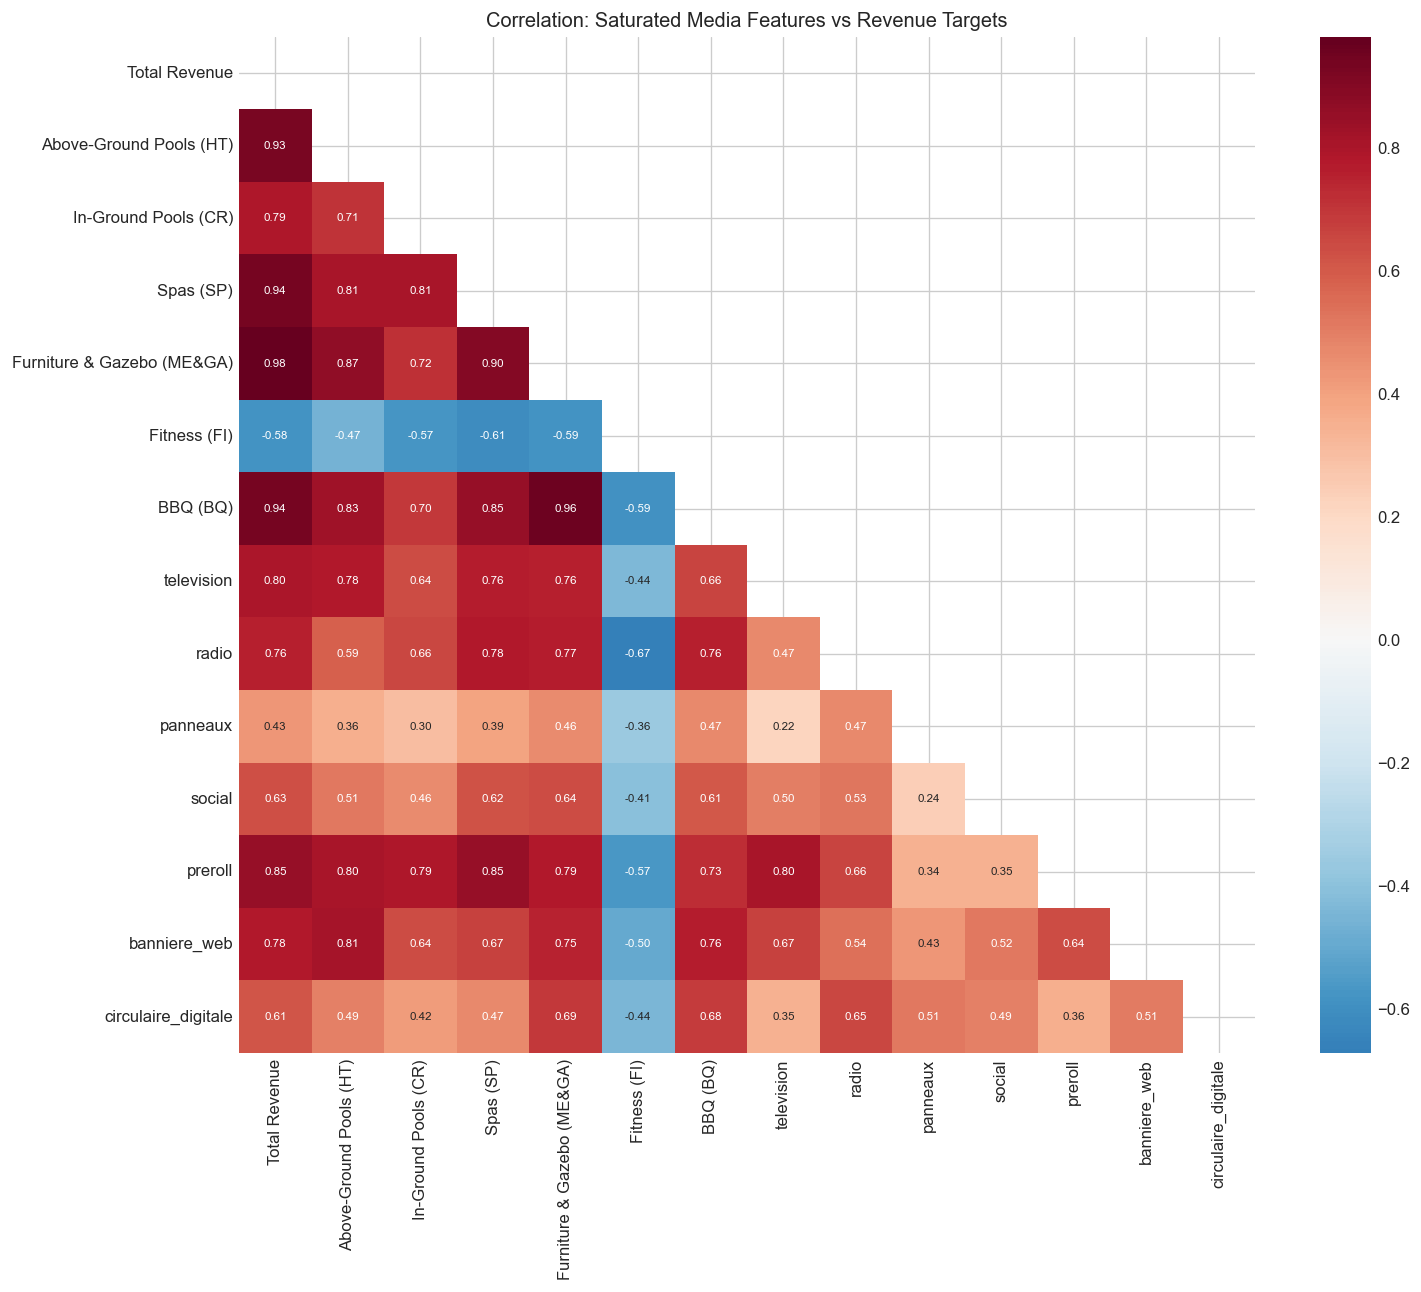

In [103]:
# ---------- Correlation matrix: saturated media + targets ----------
corr_cols = TARGET_COLS + SATURATED_COLS
corr_mat  = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
labels = [PRODUCT_LABELS.get(c, c.replace('media_', '').replace('_saturated', ''))
          for c in corr_cols]
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, xticklabels=labels, yticklabels=labels, square=True,
            annot_kws={'size': 7})
ax.set_title('Correlation: Saturated Media Features vs Revenue Targets')
plt.savefig(figures_path / 'causal_correlation_matrix.png', dpi=150)
plt.show()

In [104]:
# ---------- VIF analysis ----------
X_vif = df[FEATURE_COLS].copy().fillna(0)
X_vif_c = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    'Feature': X_vif_c.columns[1:],
    'VIF': [variance_inflation_factor(X_vif_c.values, i+1) for i in range(len(FEATURE_COLS))]
}).sort_values('VIF', ascending=False)

print('Variance Inflation Factors (VIF > 5 indicates concern):')
print(vif_data.to_string(index=False))

Variance Inflation Factors (VIF > 5 indicates concern):
                            Feature       VIF
                              cos_1 12.034018
            media_preroll_saturated 10.747475
         media_television_saturated  7.982108
              media_radio_saturated  7.901545
       media_banniere_web_saturated  5.022568
                              sin_1  4.297528
    total_sunshine_hours_dev_scaled  3.170327
     total_precipitation_dev_scaled  3.061523
       media_social_media_saturated  3.029809
media_circulaire_digitale_saturated  2.621966
           media_panneaux_saturated  1.660069
           days_above_25_dev_scaled  1.275309


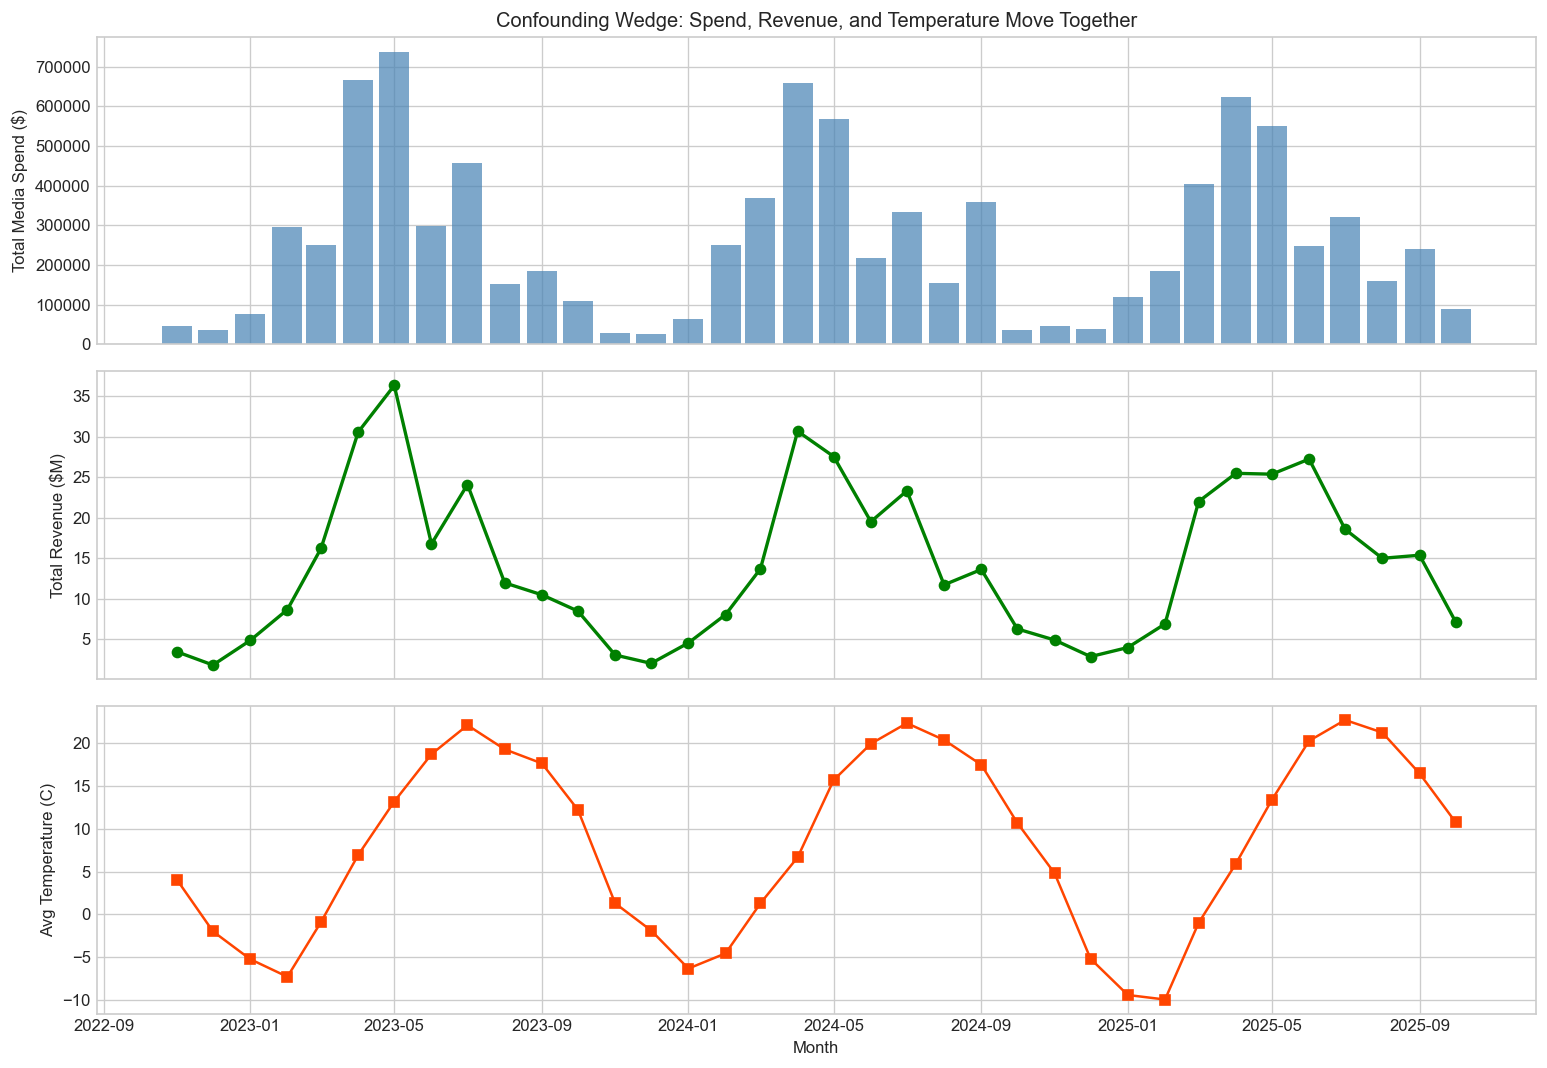

In [105]:
# ---------- Confounding wedge: spend, revenue, temperature ----------
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

ax0 = axes[0]
ax0.bar(df['date'], df['media_total'], width=25, color='steelblue', alpha=0.7)
ax0.set_ylabel('Total Media Spend ($)')
ax0.set_title('Confounding Wedge: Spend, Revenue, and Temperature Move Together')

ax1 = axes[1]
ax1.plot(df['date'], df['total_all_revenue'] / 1e6, color='green', marker='o', linewidth=2)
ax1.set_ylabel('Total Revenue ($M)')

ax2 = axes[2]
ax2.plot(df['date'], df['avg_temp_mean'], color='orangered', marker='s')
ax2.set_ylabel('Avg Temperature (C)')
ax2.set_xlabel('Month')

plt.tight_layout()
plt.savefig(figures_path / 'causal_confounding_wedge.png', dpi=150)
plt.show()

**Take-away:** All three series rise and fall together.  
Naive correlation of spend with revenue would overstate the true media effect because warm weather independently drives both ad budgets and consumer demand.  
Ridge regression with weather and Fourier seasonality controls is our main strategy to disentangle media impact from the seasonal confound.

---
## Section 3 — Model 1: OLS Baseline (per product)

In [106]:
# ---------- OLS — total revenue only (baseline) ----------
X_ols = sm.add_constant(df[FEATURE_COLS].fillna(0))

target = 'total_all_revenue'
y = df[target].values
model_ols = sm.OLS(y, X_ols).fit()

print('=' * 72)
print(f'OLS — {PRODUCT_LABELS[target]}')
print('=' * 72)
print(model_ols.summary2())
print()
print(f'Note: With {len(FEATURE_COLS)} features and {len(df)} observations, ')
print(f'OLS has {len(df) - len(FEATURE_COLS) - 1} residual df — overfitting risk is moderate.')
print(f'Ridge regression mitigates this via shrinkage.')

OLS — Total Revenue
                                     Results: Ordinary least squares
Model:                           OLS                           Adj. R-squared:                  0.887     
Dependent Variable:              y                             AIC:                             1191.5879 
Date:                            2026-02-25 00:46              BIC:                             1212.1736 
No. Observations:                36                            Log-Likelihood:                  -582.79   
Df Model:                        12                            F-statistic:                     23.83     
Df Residuals:                    23                            Prob (F-statistic):              3.88e-10  
R-squared:                       0.926                         Scale:                           1.0555e+13
----------------------------------------------------------------------------------------------------------
                                        Coef.       Std

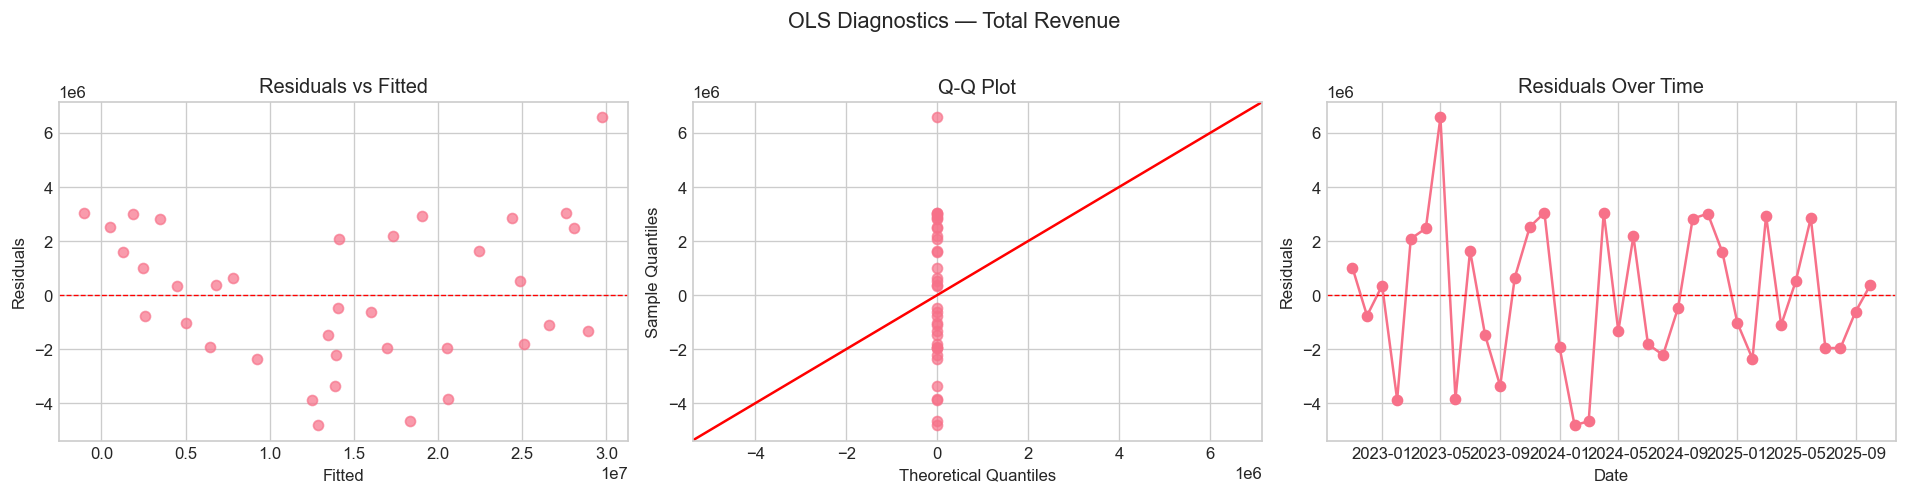

In [107]:
# ---------- OLS diagnostic plots (total revenue only) ----------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

resid = model_ols.resid
fitted = model_ols.fittedvalues

ax = axes[0]
ax.scatter(fitted, resid, alpha=0.7)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Fitted'); ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')

ax = axes[1]
sm.qqplot(resid, line='45', ax=ax, alpha=0.7)
ax.set_title('Q-Q Plot')

ax = axes[2]
ax.plot(df['date'], resid, marker='o')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Date'); ax.set_ylabel('Residuals')
ax.set_title('Residuals Over Time')

fig.suptitle(f'OLS Diagnostics — {PRODUCT_LABELS[target]}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'causal_ols_diagnostics.png', dpi=150)
plt.show()

---
## Section 4 — Model 2: Two-Stage Ridge Regression (Primary Model)

### FIX 3: Seasonality-First Decomposition

**Problem:** When media spend and seasonality controls enter the same regression,
they compete for overlapping variance (both peak in summer). With only N=36,
the model can't reliably separate them, causing media to absorb seasonal demand.

**Solution (Meta/Robyn approach):** Two-stage estimation:
1. **Stage 1:** Regress revenue on controls only (Fourier + weather deviations).
   This captures the seasonal baseline — the revenue pattern that would exist
   regardless of advertising.
2. **Stage 2:** Regress the **residuals** (revenue minus seasonal pattern) on
   media features only. Media coefficients now represent the *incremental* lift
   above and beyond the seasonal baseline.

**Why this works:** By removing seasonality first, media can no longer "steal credit"
from summer demand. The media coefficients reflect only the portion of revenue
that co-varies with media *after accounting for seasonality*.

Ridge shrinks coefficients toward zero, stabilising estimates when
predictors are correlated and N is small.
Alpha is selected via **TimeSeriesSplit cross-validation** (5 folds).

In [108]:
# ==========================================================================
# FIX 3: TWO-STAGE RIDGE REGRESSION
# Stage 1: Revenue ~ Controls (seasonality + weather)
# Stage 2: Residuals ~ Media (saturated channels)
# ==========================================================================
np.random.seed(42)

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
ALPHAS = np.logspace(-2, 4, 200)

# ---- STAGE 1: Seasonal baseline (controls only) ----
scaler_ctrl = StandardScaler()
X_ctrl_scaled = scaler_ctrl.fit_transform(df[CONTROL_COLS].fillna(0))

stage1_results = {}
residuals = {}

print('STAGE 1: Revenue ~ Controls (seasonal baseline)')
print('=' * 70)
for target in TARGET_COLS:
    y = df[target].values

    ridge_s1 = RidgeCV(alphas=ALPHAS, scoring='neg_mean_squared_error', cv=tscv)
    ridge_s1.fit(X_ctrl_scaled, y)

    model_s1 = Ridge(alpha=ridge_s1.alpha_)
    model_s1.fit(X_ctrl_scaled, y)

    y_seasonal = model_s1.predict(X_ctrl_scaled)
    resid = y - y_seasonal
    r2_s1 = r2_score(y, y_seasonal)

    stage1_results[target] = {
        'model': model_s1,
        'y_seasonal': y_seasonal,
        'r2': r2_s1,
        'alpha': ridge_s1.alpha_,
    }
    residuals[target] = resid

    print(f'  {PRODUCT_LABELS[target]:30s}  alpha={ridge_s1.alpha_:>9.2f}   '
          f'R2_seasonal={r2_s1:.3f}   residual_std=${resid.std():,.0f}')

# ---- STAGE 2: Residuals ~ Media (incremental lift) ----
scaler_media = StandardScaler()
X_media_scaled = scaler_media.fit_transform(df[SATURATED_COLS].fillna(0))

# Also keep a combined scaler for the full feature set (needed for backward compat)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURE_COLS].fillna(0))

ridge_results = {}

print(f'\nSTAGE 2: Residuals ~ Media (incremental media lift)')
print('=' * 70)
for target in TARGET_COLS:
    y_resid = residuals[target]

    ridge_s2 = RidgeCV(alphas=ALPHAS, scoring='neg_mean_squared_error', cv=tscv)
    ridge_s2.fit(X_media_scaled, y_resid)

    model_s2 = Ridge(alpha=ridge_s2.alpha_)
    model_s2.fit(X_media_scaled, y_resid)

    y_pred_media = model_s2.predict(X_media_scaled)

    # Full prediction = seasonal + media
    y_seasonal = stage1_results[target]['y_seasonal']
    y_pred_full = y_seasonal + y_pred_media
    y_actual = df[target].values

    r2_full = r2_score(y_actual, y_pred_full)
    r2_media = r2_score(y_resid, y_pred_media) if y_resid.std() > 0 else 0
    mae = mean_absolute_error(y_actual, y_pred_full)

    # TimeSeriesSplit CV on Stage 2
    from sklearn.model_selection import cross_val_score
    cv_scores = cross_val_score(model_s2, X_media_scaled, y_resid,
                                cv=tscv, scoring='neg_mean_squared_error')
    # Convert to approximate R2
    ss_res_cv = -cv_scores.mean() * len(y_resid)
    ss_tot = np.sum((y_resid - y_resid.mean())**2)
    r2_cv_approx = 1 - ss_res_cv / ss_tot if ss_tot > 0 else 0

    ridge_results[target] = {
        'model_s1':     stage1_results[target]['model'],
        'model_s2':     model_s2,
        'best_alpha':   ridge_s2.alpha_,
        'r2':           r2_full,
        'r2_s1':        stage1_results[target]['r2'],
        'r2_s2':        r2_media,
        'r2_cv':        r2_cv_approx,
        'mae':          mae,
        'y_pred':       y_pred_full,
        'y_seasonal':   y_seasonal,
        'y_media':      y_pred_media,
    }

    print(f'  {PRODUCT_LABELS[target]:30s}  alpha={ridge_s2.alpha_:>9.2f}   '
          f'R2_full={r2_full:.3f}   R2_media={r2_media:.3f}   MAE=${mae:,.0f}')

print(f'\nFIX 3: Two-stage Ridge (Robyn-style seasonality-first decomposition)')
print(f'FIX 4: TimeSeriesSplit CV (5 folds) for alpha selection')
print(f'Stage 1 captures seasonal baseline; Stage 2 captures media lift on residuals')

STAGE 1: Revenue ~ Controls (seasonal baseline)
  Total Revenue                   alpha=     2.10   R2_seasonal=0.835   residual_std=$3,869,071
  Above-Ground Pools (HT)         alpha=     6.83   R2_seasonal=0.716   residual_std=$1,350,841
  In-Ground Pools (CR)            alpha=     1.29   R2_seasonal=0.550   residual_std=$454,544
  Spas (SP)                       alpha=     1.05   R2_seasonal=0.786   residual_std=$923,743
  Furniture & Gazebo (ME&GA)      alpha=     1.29   R2_seasonal=0.838   residual_std=$1,844,501
  Fitness (FI)                    alpha=     3.65   R2_seasonal=0.577   residual_std=$84,252
  BBQ (BQ)                        alpha=     1.05   R2_seasonal=0.795   residual_std=$160,244

STAGE 2: Residuals ~ Media (incremental media lift)
  Total Revenue                   alpha=    89.07   R2_full=0.860   R2_media=0.155   MAE=$2,796,210
  Above-Ground Pools (HT)         alpha=   252.35   R2_full=0.751   R2_media=0.122   MAE=$827,741
  In-Ground Pools (CR)            alph

In [109]:
# ---------- Bootstrap for coefficient confidence intervals ----------
# FIX 3: Bootstrap on Stage 2 (media-only model on residuals)
N_BOOT = 1000
boot_coefs = {t: [] for t in TARGET_COLS}

n = len(df)
rng = np.random.RandomState(42)

for b in range(N_BOOT):
    idx = rng.choice(n, size=n, replace=True)
    X_b = X_media_scaled[idx]
    for target in TARGET_COLS:
        y_b = residuals[target][idx]
        alpha_b = ridge_results[target]['best_alpha']
        m = Ridge(alpha=alpha_b).fit(X_b, y_b)
        boot_coefs[target].append(m.coef_)

# Summarise bootstrap
boot_summary = {}
for target in TARGET_COLS:
    arr = np.array(boot_coefs[target])
    boot_summary[target] = pd.DataFrame({
        'feature':  SATURATED_COLS,
        'coef':     ridge_results[target]['model_s2'].coef_,
        'boot_mean': arr.mean(axis=0),
        'ci_lower': np.percentile(arr, 5,  axis=0),
        'ci_upper': np.percentile(arr, 95, axis=0),
    })

print('Bootstrap done (1,000 resamples on Stage 2 residuals).  90% CI computed.')

Bootstrap done (1,000 resamples on Stage 2 residuals).  90% CI computed.


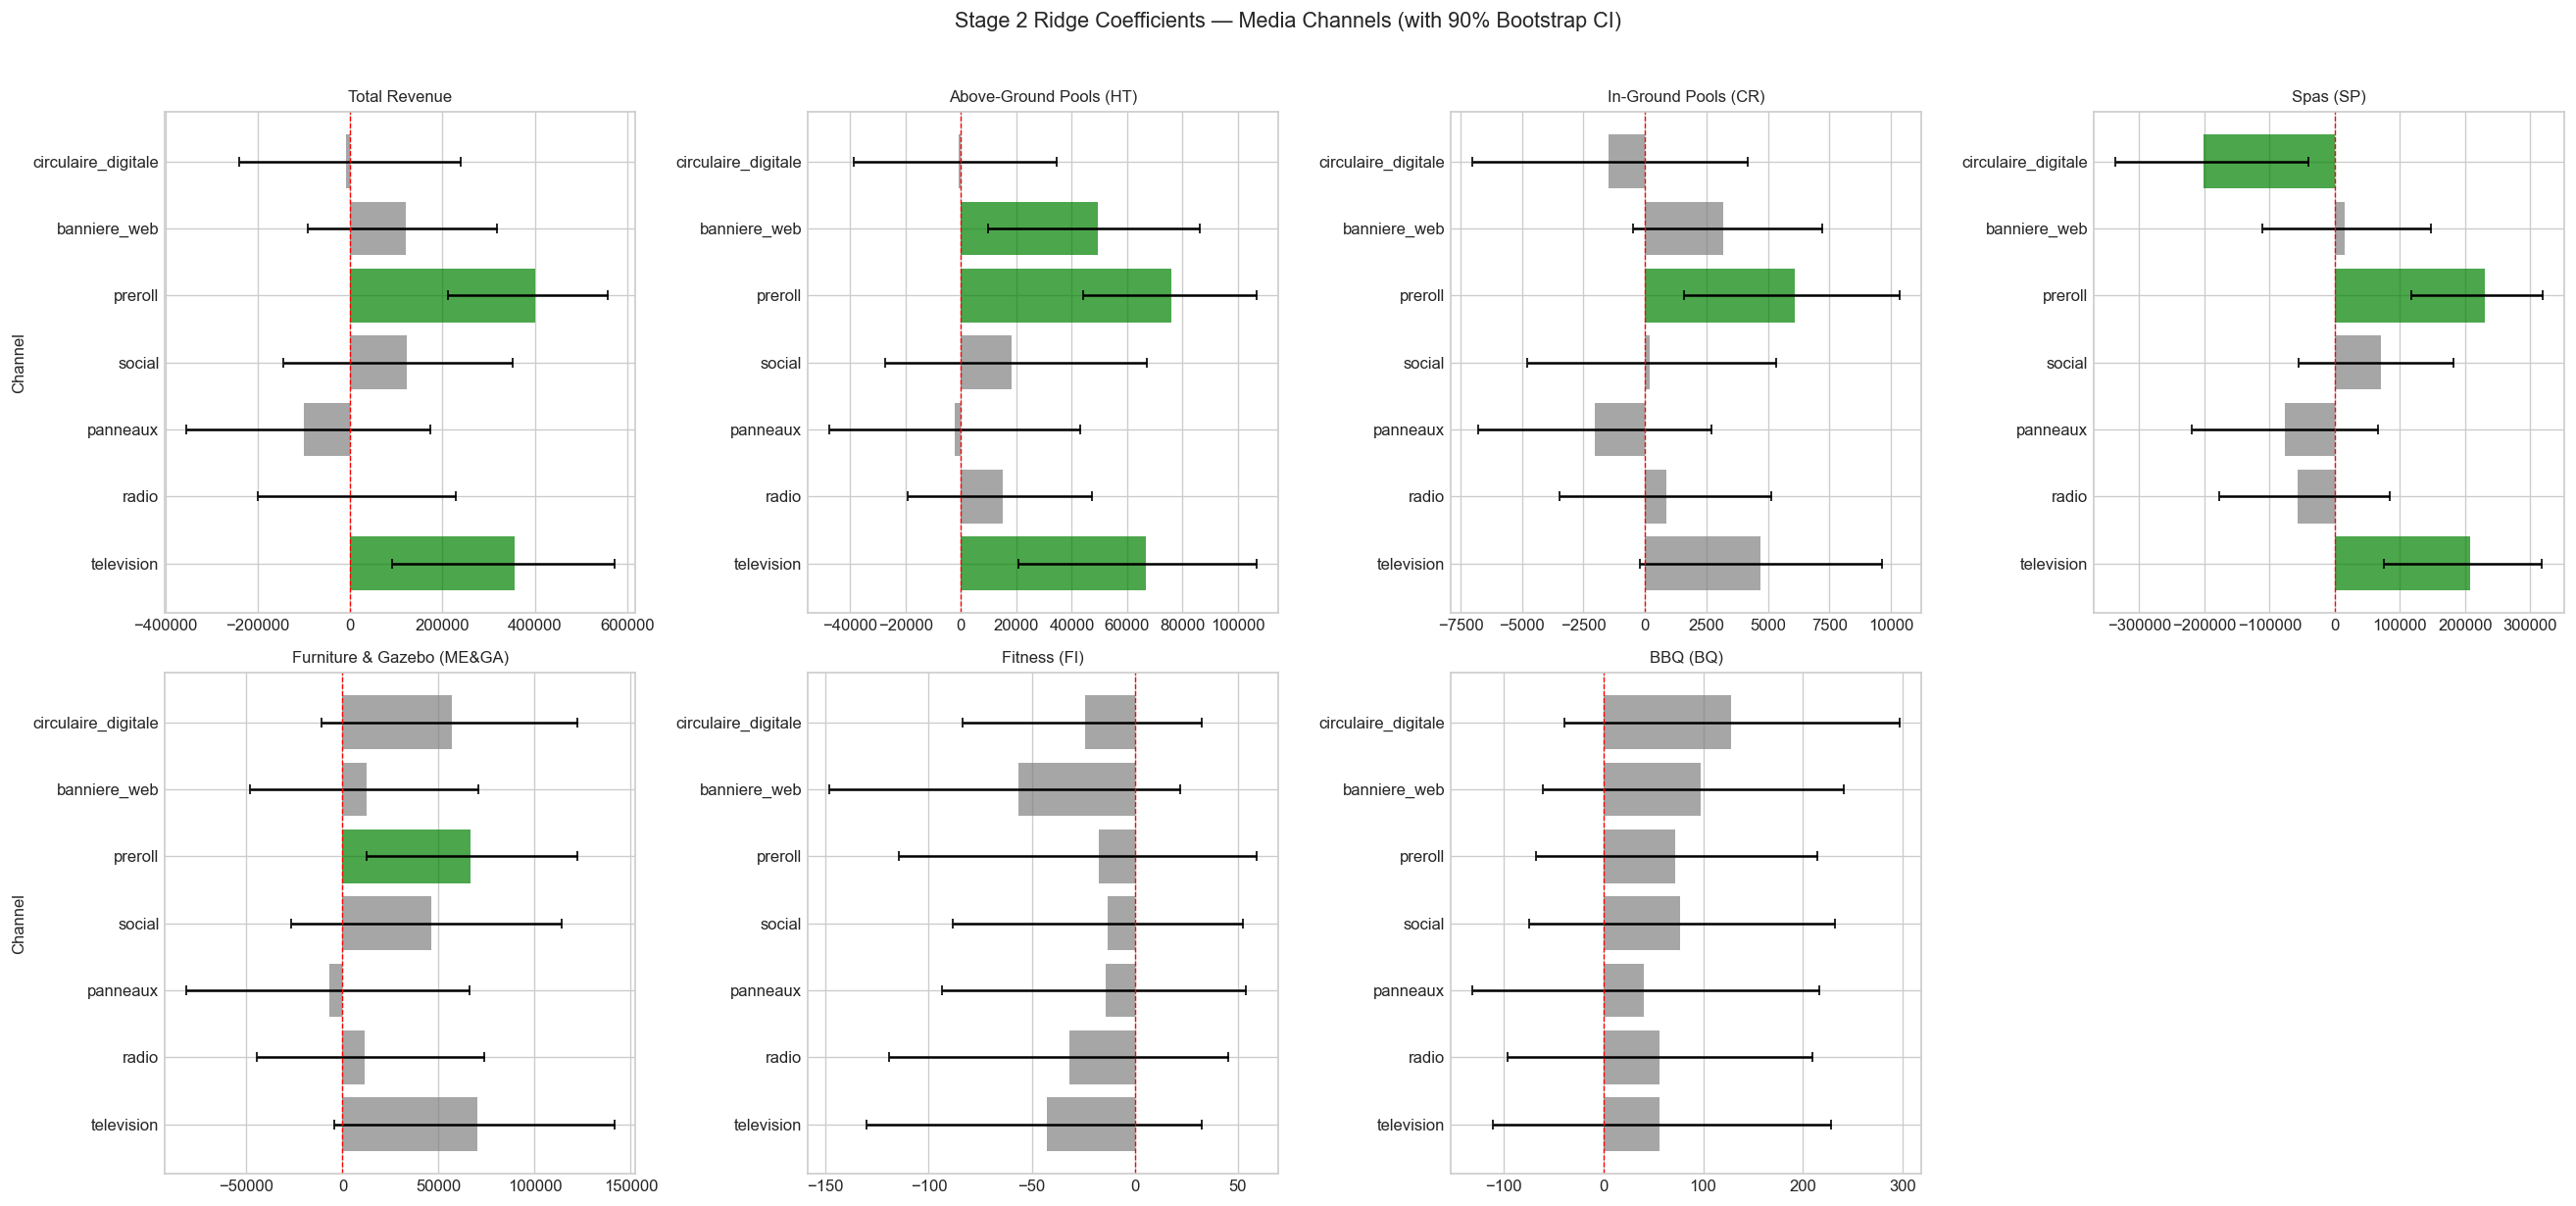

In [110]:
# ---------- Coefficient bar charts with CI (2x4 grid for 7 targets) ----------
# FIX 3: Uses Stage 2 (media-only) coefficients
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    bs = boot_summary[target]
    media_bs = bs.copy()
    media_bs['label'] = media_bs['feature'].str.replace('media_', '').str.replace('_saturated', '')

    colors = ['green' if (lo > 0 or hi < 0) else 'grey'
              for lo, hi in zip(media_bs['ci_lower'], media_bs['ci_upper'])]
    ax.barh(media_bs['label'], media_bs['coef'], color=colors, alpha=0.7)
    ax.errorbar(media_bs['coef'], media_bs['label'],
                xerr=[media_bs['coef'] - media_bs['ci_lower'],
                      media_bs['ci_upper'] - media_bs['coef']],
                fmt='none', ecolor='black', capsize=3)
    ax.axvline(0, color='red', linestyle='--', linewidth=0.8)
    ax.set_title(f'{PRODUCT_LABELS[target]}', fontsize=10)
    if idx in [0, 4]:
        ax.set_ylabel('Channel')

fig.delaxes(axes[-1])
fig.suptitle('Stage 2 Ridge Coefficients — Media Channels (with 90% Bootstrap CI)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'causal_ridge_coefficients.png', dpi=150)
plt.show()

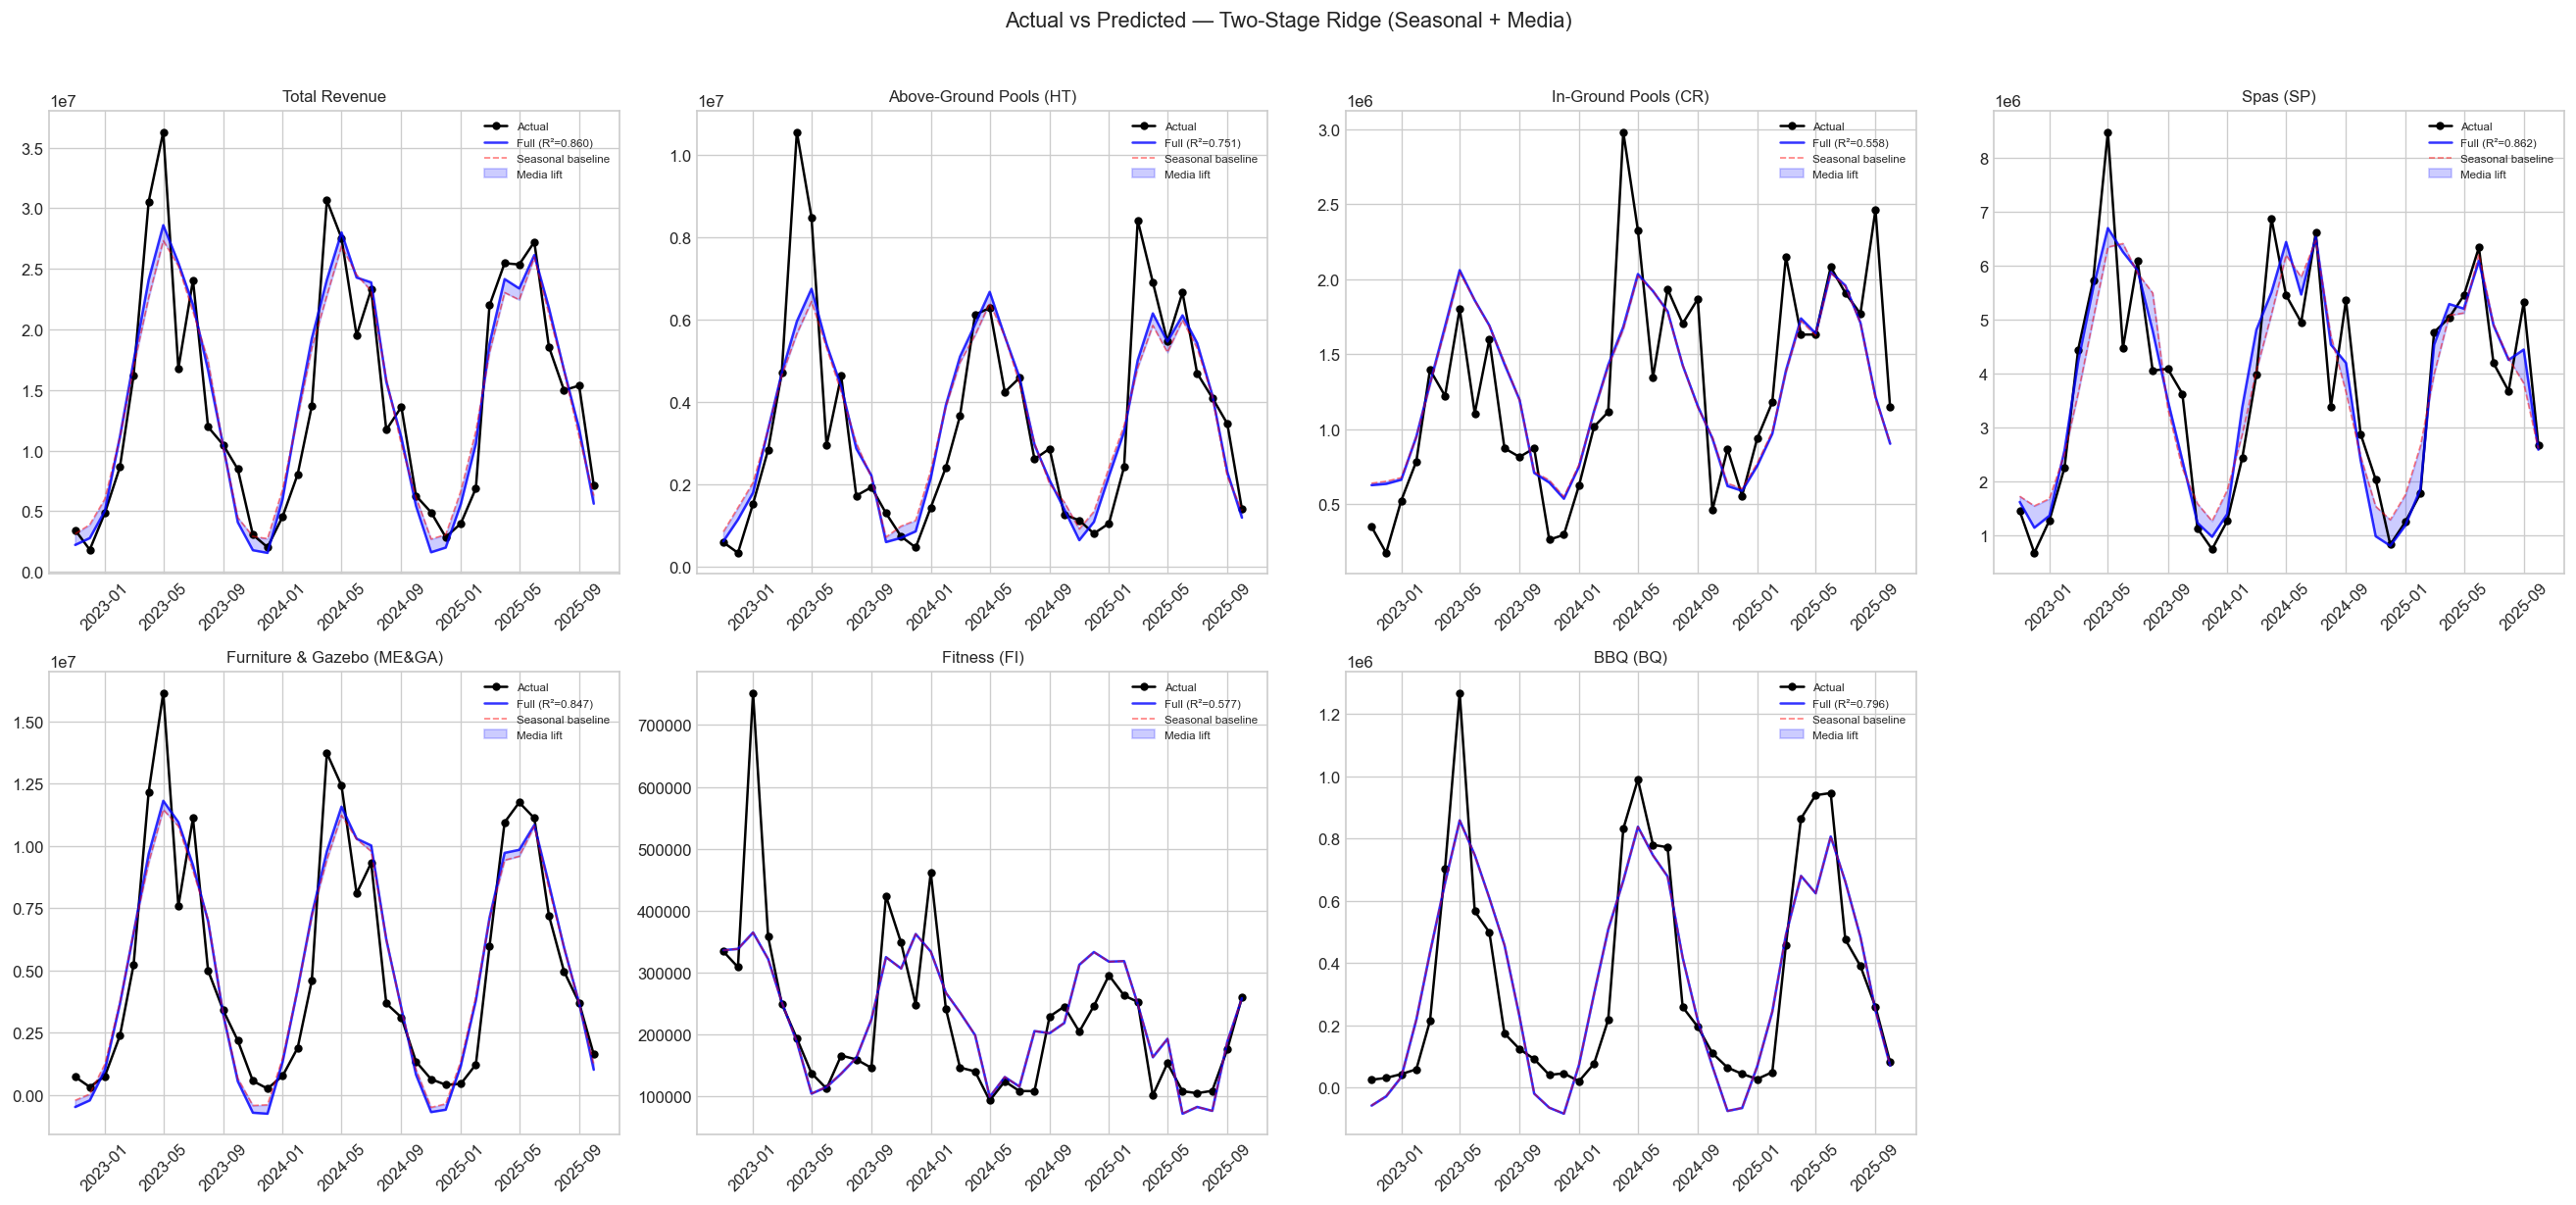

In [111]:
# ---------- Actual vs predicted (2x4 grid) ----------
# FIX 3: Shows Stage 1 (seasonal) + Stage 2 (media) = full prediction
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    y_actual = df[target].values
    y_pred = ridge_results[target]['y_pred']
    y_seasonal = ridge_results[target]['y_seasonal']
    r2 = ridge_results[target]['r2']

    ax.plot(df['date'], y_actual, 'ko-', markersize=4, label='Actual', linewidth=1.5)
    ax.plot(df['date'], y_pred, 'b-', alpha=0.8, label=f'Full (R²={r2:.3f})', linewidth=1.5)
    ax.plot(df['date'], y_seasonal, 'r--', alpha=0.5, label=f'Seasonal baseline', linewidth=1)
    ax.fill_between(df['date'], y_seasonal, y_pred, alpha=0.2, color='blue', label='Media lift')
    ax.set_title(f'{PRODUCT_LABELS[target]}', fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=45)

fig.delaxes(axes[-1])
fig.suptitle('Actual vs Predicted — Two-Stage Ridge (Seasonal + Media)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'causal_ridge_actual_vs_pred.png', dpi=150)
plt.show()

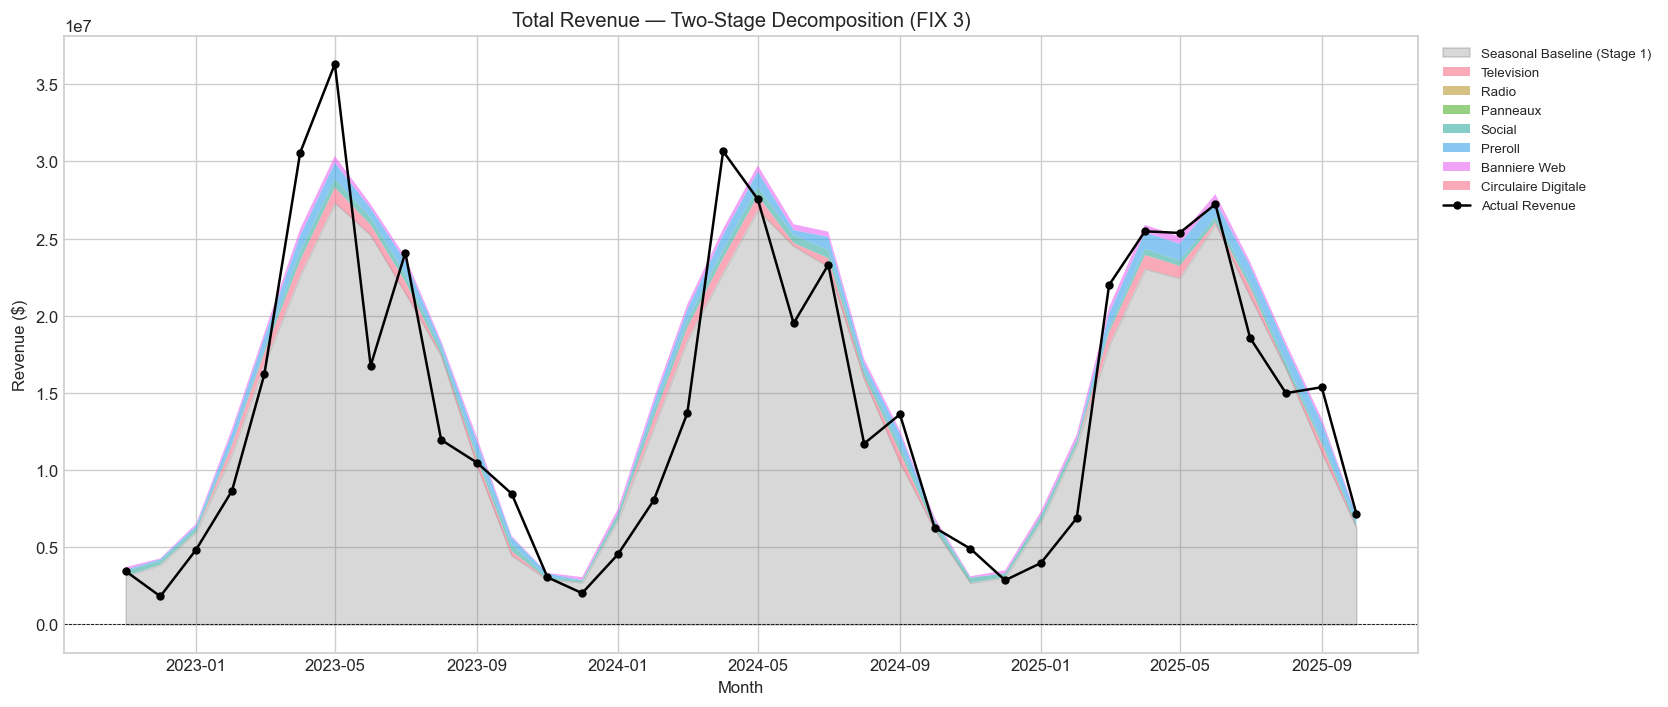


  TWO-STAGE CONTRIBUTION DECOMPOSITION — Total Revenue
  Seasonal Baseline (Stage 1): $   512,411,602  (100.0%)
  S2 Intercept (unmatch resid): $   -53,826,346  (-10.5%)
  television                      $    14,053,535  (  2.7%)
  radio                           $       -49,783  ( -0.0%)
  panneaux                        $    -3,356,425  ( -0.7%)
  social                          $    13,033,472  (  2.5%)
  preroll                         $    20,863,982  (  4.1%)
  banniere_web                    $     9,699,396  (  1.9%)
  circulaire_digitale             $      -417,832  ( -0.1%)
  TOTAL BASELINE                  $   458,585,256  ( 89.5%)
  TOTAL MEDIA                     $    53,826,346  ( 10.5%)
  SUM CHECK                       $   512,411,602  (100.0%)
  ACTUAL REVENUE                  $   512,411,602  (100.0%)

--- Sanity Checks ---
✅  Positive baseline: $458,585,256 (89.5%)
✅  Media contribution in plausible range: 10.5%
⚠️  Negative channels: [('radio', '$-49,783'), ('pannea

In [112]:
# ---------- Media contribution decomposition (total revenue only) ----------
# FIX 3: Two-stage decomposition:
#   Revenue = Seasonal Baseline + Media Lift + Residual
# The seasonal baseline is the Stage 1 prediction (controls only).
# Media lift is the Stage 2 prediction (media on residuals).
# This guarantees media cannot absorb seasonal demand.

target = 'total_all_revenue'
y_actual = df[target].values
y_seasonal = ridge_results[target]['y_seasonal']
model_s2 = ridge_results[target]['model_s2']

# ---- Per-channel media contributions (Stage 2, original space) ----
beta_s2_std = model_s2.coef_
beta_s2_orig = beta_s2_std / scaler_media.scale_

# Per-channel, per-period contributions
X_media_orig = df[SATURATED_COLS].fillna(0).values
media_contribs_orig = X_media_orig * beta_s2_orig  # broadcasting

media_contribs = pd.DataFrame(
    media_contribs_orig,
    columns=[c.replace('media_', '').replace('_saturated', '') for c in SATURATED_COLS]
)

# Intercept of Stage 2 = average residual not explained by media
s2_intercept_orig = model_s2.intercept_ - np.sum(beta_s2_std * scaler_media.mean_ / scaler_media.scale_)

# ---- Waterfall stacked area chart ----
fig, ax = plt.subplots(figsize=(14, 6))

# Seasonal baseline from Stage 1
ax.fill_between(df['date'], 0, y_seasonal, alpha=0.3,
                label=f'Seasonal Baseline (Stage 1)', color='grey')

# Stack media contributions on top
bottom = y_seasonal.copy()
for col in media_contribs.columns:
    vals = media_contribs[col].values
    vals_pos = np.clip(vals, 0, None)
    ax.fill_between(df['date'], bottom, bottom + vals_pos, alpha=0.6,
                    label=col.replace('_', ' ').title())
    bottom = bottom + vals_pos

ax.plot(df['date'], y_actual, 'ko-', markersize=4, label='Actual Revenue', linewidth=1.5)
ax.set_ylabel('Revenue ($)')
ax.set_title(f'{PRODUCT_LABELS[target]} — Two-Stage Decomposition (FIX 3)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xlabel('Month')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig(figures_path / 'causal_media_decomposition.png', dpi=150)
plt.show()

# ---- Summary statistics ----
total_revenue = y_actual.sum()
total_seasonal = y_seasonal.sum()
total_media_contrib = media_contribs.values.sum()
total_s2_intercept = s2_intercept_orig * len(df)
model_residual = total_revenue - total_seasonal - total_media_contrib - total_s2_intercept

print(f'\n{"=" * 70}')
print(f'  TWO-STAGE CONTRIBUTION DECOMPOSITION — {PRODUCT_LABELS[target]}')
print(f'{"=" * 70}')
print(f'  Seasonal Baseline (Stage 1): ${total_seasonal:>14,.0f}  ({total_seasonal/total_revenue*100:>5.1f}%)')
print(f'  S2 Intercept (unmatch resid): ${total_s2_intercept:>14,.0f}  ({total_s2_intercept/total_revenue*100:>5.1f}%)')
for col in media_contribs.columns:
    val = media_contribs[col].sum()
    print(f'  {col:30s}  ${val:>14,.0f}  ({val/total_revenue*100:>5.1f}%)')
total_base = total_seasonal + total_s2_intercept
print(f'  {"TOTAL BASELINE":30s}  ${total_base:>14,.0f}  ({total_base/total_revenue*100:>5.1f}%)')
print(f'  {"TOTAL MEDIA":30s}  ${total_media_contrib:>14,.0f}  ({total_media_contrib/total_revenue*100:>5.1f}%)')
print(f'  {"SUM CHECK":30s}  ${total_base+total_media_contrib:>14,.0f}  ({(total_base+total_media_contrib)/total_revenue*100:>5.1f}%)')
print(f'  {"ACTUAL REVENUE":30s}  ${total_revenue:>14,.0f}  (100.0%)')

# ---- FIX 5: Sanity checks ----
media_pct = total_media_contrib / total_revenue * 100
base_pct = total_base / total_revenue * 100
print(f'\n--- Sanity Checks ---')
issues = []

if total_base < 0:
    issues.append(f'⚠️  Negative total baseline: ${total_base:,.0f} ({base_pct:.1f}%)')
else:
    print(f'✅  Positive baseline: ${total_base:,.0f} ({base_pct:.1f}%)')

if media_pct > 80:
    issues.append(f'⚠️  Media > 80%: {media_pct:.1f}%')
elif media_pct < 0:
    issues.append(f'⚠️  Negative total media: {media_pct:.1f}%')
elif media_pct > 50:
    print(f'⚠️  Media is high but plausible: {media_pct:.1f}% (industry range: 10-40% for retail)')
else:
    print(f'✅  Media contribution in plausible range: {media_pct:.1f}%')

neg_channels = [(col, media_contribs[col].sum()) for col in media_contribs.columns if media_contribs[col].sum() < 0]
if neg_channels:
    issues.append(f'⚠️  Negative channels: {[(c, f"${v:,.0f}") for c, v in neg_channels]}')
else:
    print(f'✅  All channel contributions are positive')

for issue in issues:
    print(issue)

if not issues:
    print(f'\n🎯 Two-stage model passes all sanity checks!')

In [113]:
# ---------- Cross-product comparison table ----------
# FIX 3: Uses Stage 2 coefficients (media on residuals)
print('Ridge Coefficients -- Media Channels (Stage 2, standardised scale)')
print('=' * 120)

rows = []
for target in TARGET_COLS:
    coefs = ridge_results[target]['model_s2'].coef_
    row = {PRODUCT_LABELS[target]: {
        SATURATED_COLS[j].replace('media_', '').replace('_saturated', ''): coefs[j]
        for j in range(len(SATURATED_COLS))
    }}
    rows.append(row)

coef_table = pd.DataFrame({k: v for r in rows for k, v in r.items()}).T
coef_table.index.name = 'Channel'
print(coef_table.to_string(float_format='{:.0f}'.format))

Ridge Coefficients -- Media Channels (Stage 2, standardised scale)
                            television  radio  panneaux  social  preroll  banniere_web  circulaire_digitale
Channel                                                                                                    
Total Revenue                   357027   -976   -100167  121553   400323        119843                -8253
Above-Ground Pools (HT)          66739  14947     -2251   18367    76093         49380                 -913
In-Ground Pools (CR)              4688    863     -2060     187     6073          3202                -1473
Spas (SP)                       206891 -57083    -75964   70285   229522         15453              -200468
Furniture & Gazebo (ME&GA)       70086  11747     -6861   46419    66557         12554                56767
Fitness (FI)                       -43    -32       -14     -13      -18           -57                  -24
BBQ (BQ)                            56     56        40      77      

---
## Section 5 — Model 3: Elastic Net (Variable Selection Check)

Elastic Net combines L1 (lasso, variable selection) and L2 (ridge) penalties.  
We use it to check **which channels get zeroed out** — i.e., which ones Lasso deems uninformative.

In [114]:
# ---------- Elastic Net on Stage 2 residuals (total revenue + 6 categories) ----------
# FIX 3: ElasticNet also runs on de-seasonalized residuals for fair comparison with Ridge Stage 2
enet_results = {}

for target in TARGET_COLS:
    y_resid = residuals[target]
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        alphas=np.logspace(-3, 2, 50),
        cv=TimeSeriesSplit(n_splits=5),
        max_iter=10_000,
    )
    enet.fit(X_media_scaled, y_resid)
    enet_results[target] = enet
    print(f'{PRODUCT_LABELS[target]:30s}  alpha={enet.alpha_:.4f}  '
          f'l1_ratio={enet.l1_ratio_:.2f}  '
          f'non-zero={np.sum(enet.coef_ != 0)}/{len(enet.coef_)}  '
          f'R2={r2_score(y_resid, enet.predict(X_media_scaled)):.3f}')

Total Revenue                   alpha=9.5410  l1_ratio=0.10  non-zero=7/7  R2=0.079
Above-Ground Pools (HT)         alpha=100.0000  l1_ratio=0.30  non-zero=7/7  R2=0.019
In-Ground Pools (CR)            alpha=30.8884  l1_ratio=0.30  non-zero=7/7  R2=0.018
Spas (SP)                       alpha=1.1514  l1_ratio=0.30  non-zero=7/7  R2=0.315
Furniture & Gazebo (ME&GA)      alpha=100.0000  l1_ratio=0.90  non-zero=7/7  R2=0.040
Fitness (FI)                    alpha=39.0694  l1_ratio=0.30  non-zero=7/7  R2=0.005
BBQ (BQ)                        alpha=100.0000  l1_ratio=0.10  non-zero=7/7  R2=0.003


In [115]:
# ---------- Coefficient comparison: Ridge vs Elastic Net (total revenue, Stage 2) ----------
# FIX 3: OLS comparison dropped (OLS was on full features; Stage 2 is media-only)
target = 'total_all_revenue'
print(f'\n{"=" * 72}')
print(f'{PRODUCT_LABELS[target]} -- Coefficient Comparison (Stage 2: media on residuals)')
print(f'{"=" * 72}')

ridge_coefs = ridge_results[target]['model_s2'].coef_
enet_coefs  = enet_results[target].coef_

comp = pd.DataFrame({
    'Feature': SATURATED_COLS,
    'Ridge_S2':    ridge_coefs,
    'ElasticNet':  enet_coefs,
})
comp['label'] = comp['Feature'].str.replace('media_', '').str.replace('_saturated', '')
comp['Ridge_nonzero'] = comp['Ridge_S2'] != 0
comp['Enet_nonzero'] = comp['ElasticNet'] != 0
comp = comp[['label', 'Ridge_S2', 'ElasticNet', 'Enet_nonzero']]
print(comp.to_string(index=False, float_format='{:>12.1f}'.format))
print(f'\nElasticNet retains {(enet_coefs != 0).sum()}/{len(enet_coefs)} channels')


Total Revenue -- Coefficient Comparison (Stage 2: media on residuals)
              label     Ridge_S2   ElasticNet  Enet_nonzero
         television     357026.9     151905.6          True
              radio       -976.3      26896.7          True
           panneaux    -100167.3     -21790.0          True
             social     121553.2      61365.9          True
            preroll     400323.4     162157.2          True
       banniere_web     119843.3      70531.9          True
circulaire_digitale      -8252.6      12998.6          True

ElasticNet retains 7/7 channels


---
## Section 6 — Channel Effectiveness Metrics (Key Deliverable)

Translate Ridge coefficients back into **business metrics**:

- Marginal effect: additional revenue per $1,000 extra spend.
- ROAS: return on ad spend for each channel.
- Saturation level: how saturated is each channel at current spend?
- Cross-product heatmap.

In [116]:
# ===================================================================
# 6-A  MARGINAL EFFECTS  (dRevenue / d$1000)
# ===================================================================
# FIX 3: Uses Stage 2 coefficients (media on de-seasonalized residuals).
# The marginal effect chain is:
#   dRevenue/d$spend = beta_s2_orig * dSaturation/dAdstock * dAdstock/d$spend
# where beta_s2_orig = beta_s2_std / scaler_media.scale_

effectiveness_rows = []

for target in TARGET_COLS:
    model_s2 = ridge_results[target]['model_s2']
    bs = boot_summary[target]

    beta_s2_std = model_s2.coef_
    beta_s2_orig = beta_s2_std / scaler_media.scale_

    for i, ch in enumerate(MEDIA_CHANNELS):
        sat_col = SATURATED_COLS[i]
        beta_std_i = beta_s2_std[i]
        beta_orig_i = beta_s2_orig[i]

        # Use median of non-zero adstock
        adstock_nz = df[f'{ch}_adstock'][df[f'{ch}_adstock'] > 0]
        adstock_eval = float(adstock_nz.median()) if len(adstock_nz) > 0 else 0

        # Hill derivative at evaluation point
        K = SATURATION_PARAMS[ch]['K']
        alpha_h = SATURATION_PARAMS[ch]['alpha']
        dS_dx = float(hill_derivative(adstock_eval, K, alpha_h))

        lam = DECAY_RATES[ch]
        adstock_gain = 1.0 / (1.0 - lam)

        # Marginal effect in original space
        marginal_per_dollar = beta_orig_i * dS_dx * adstock_gain
        marginal_per_1000 = marginal_per_dollar * 1000
        roas = marginal_per_dollar

        total_spend = df[ch].sum()

        # Contribution in original space
        contrib = beta_orig_i * df[sat_col].sum()
        contrib_pct = contrib / df[target].sum() * 100

        current_sat = float(df[sat_col].mean()) * 100

        # Bootstrap CI (un-standardized using scaler_media)
        boot_arr = np.array(boot_coefs[target])[:, i]
        boot_beta_orig = boot_arr / scaler_media.scale_[i]
        boot_marginals = boot_beta_orig * dS_dx * adstock_gain * 1000
        ci_lo = float(np.percentile(boot_marginals, 5))
        ci_hi = float(np.percentile(boot_marginals, 95))

        effectiveness_rows.append({
            'product':     PRODUCT_LABELS[target],
            'channel':     ch.replace('media_', ''),
            'total_spend': total_spend,
            'ridge_coef_std': beta_std_i,
            'ridge_coef_orig': beta_orig_i,
            'marginal_per_1000': marginal_per_1000,
            'marginal_ci_lo': ci_lo,
            'marginal_ci_hi': ci_hi,
            'roas': roas,
            'total_contribution': contrib,
            'contribution_pct': contrib_pct,
            'saturation_pct': current_sat,
        })

eff_df = pd.DataFrame(effectiveness_rows)

# Display for total revenue
target = 'total_all_revenue'
label = PRODUCT_LABELS[target]
print(f'\n{"=" * 120}')
print(f'  {label} — Channel Effectiveness (Two-Stage Ridge, original-space coefficients)')
print(f'{"=" * 120}')
sub = eff_df[eff_df['product'] == label].copy()
sub = sub.sort_values('marginal_per_1000', ascending=False)
display_cols = ['channel', 'total_spend', 'marginal_per_1000',
                'marginal_ci_lo', 'marginal_ci_hi', 'roas',
                'total_contribution', 'contribution_pct', 'saturation_pct']
print(sub[display_cols].to_string(index=False, float_format='{:.2f}'.format))


  Total Revenue — Channel Effectiveness (Two-Stage Ridge, original-space coefficients)
            channel  total_spend  marginal_per_1000  marginal_ci_lo  marginal_ci_hi   roas  total_contribution  contribution_pct  saturation_pct
            preroll    902393.38           28226.88        14973.93        39393.58  28.23         20863982.31              4.07           45.36
       social_media    827420.60           17050.28       -20419.18        49294.71  17.05         13033472.33              2.54           51.90
       banniere_web    827607.24           13438.83       -10217.17        35591.65  13.44          9699395.83              1.89           49.83
         television   3948951.24            4525.30         1155.31         7246.78   4.53         14053535.20              2.74           36.83
              radio   2167276.63             -28.27        -5768.19         6615.83  -0.03           -49783.27             -0.01           44.84
circulaire_digitale    446545.72          

### 6-B — Channel Effectiveness Summary Table

The table below translates Ridge regression coefficients into **business-actionable metrics**.

**How to read this table:**
- **$/1K Spent**: For every additional $1,000 spent on this channel, how much incremental revenue does the model estimate? Computed at the current (median) spend level — at higher spend, diminishing returns apply.
- **90% CI**: The range of plausible values from 1,000 bootstrap resamples.
- **Significant?**: A channel is **statistically significant** if its 90% bootstrap confidence interval **does not include zero**. This means we can be at least 90% confident the true effect is not just noise.
- **ROAS**: Return on Ad Spend = revenue per $1 spent. ROAS > 1 means the channel generates more revenue than it costs.
- **Saturation %**: How close the channel is to its diminishing-returns ceiling. Higher = less room to grow.

In [117]:
# ===================================================================
# 6-B  FORMATTED EFFECTIVENESS TABLE (Total Revenue)
# ===================================================================

# Build summary table for Total Revenue
eff_total = eff_df[eff_df['product'] == 'Total Revenue'].copy()
eff_total = eff_total.sort_values('marginal_per_1000', ascending=False)

CHANNEL_LABELS_SHORT = {
    'television': 'Television',
    'radio': 'Radio',
    'panneaux': 'Panneaux (Outdoor)',
    'social_media': 'Social Media',
    'preroll': 'Preroll (Video)',
    'banniere_web': 'Web Banners',
    'circulaire_digitale': 'Digital Flyers',
}

summary_rows = []
for _, row in eff_total.iterrows():
    ch = row['channel']
    label = CHANNEL_LABELS_SHORT.get(ch, ch)
    ci_lo = row['marginal_ci_lo']
    ci_hi = row['marginal_ci_hi']
    significant = ci_lo > 0 or ci_hi < 0  # CI excludes zero
    roas = row['roas']
    
    summary_rows.append({
        'Channel': label,
        'Total Spend (3Y)': f'${row["total_spend"]:,.0f}',
        '$/1K Spent': f'${row["marginal_per_1000"]:,.0f}',
        '90% CI Lower': f'${ci_lo:,.0f}',
        '90% CI Upper': f'${ci_hi:,.0f}',
        'Significant?': 'YES' if significant else 'no',
        'ROAS': f'{roas:.1f}' if roas > 0 else f'{roas:.1f} (negative)',
        'Saturation %': f'{row["saturation_pct"]:.1f}%',
    })

summary_table = pd.DataFrame(summary_rows)

# Display with styling
print('=' * 120)
print('  CHANNEL EFFECTIVENESS — TOTAL REVENUE')
print('  How much incremental revenue does each $1,000 of additional spend generate?')
print('=' * 120)
print()
print(summary_table.to_string(index=False))
print()
print('─' * 120)
print('SIGNIFICANCE: A channel is significant if its 90% bootstrap CI does NOT include zero.')
print('  → Significant channels: the data provides strong evidence of a real positive media effect.')
print('  → Non-significant channels: the effect could plausibly be zero — we cannot rule out noise.')
print('  → This does NOT mean the channel has no effect — only that 36 months of data is insufficient to prove it.')
print()

# Count significant
n_sig = sum(1 for r in summary_rows if r['Significant?'] == 'YES')
print(f'Significant channels: {n_sig} / {len(summary_rows)}')
sig_names = [r['Channel'] for r in summary_rows if r['Significant?'] == 'YES']
print(f'  → {sig_names}')


  CHANNEL EFFECTIVENESS — TOTAL REVENUE
  How much incremental revenue does each $1,000 of additional spend generate?

           Channel Total Spend (3Y) $/1K Spent 90% CI Lower 90% CI Upper Significant?             ROAS Saturation %
   Preroll (Video)         $902,393    $28,227      $14,974      $39,394          YES             28.2        45.4%
      Social Media         $827,421    $17,050     $-20,419      $49,295           no             17.1        51.9%
       Web Banners         $827,607    $13,439     $-10,217      $35,592           no             13.4        49.8%
        Television       $3,948,951     $4,525       $1,155       $7,247          YES              4.5        36.8%
             Radio       $2,167,277       $-28      $-5,768       $6,616           no  -0.0 (negative)        44.8%
    Digital Flyers         $446,546    $-1,321     $-38,359      $38,294           no  -1.3 (negative)        46.9%
Panneaux (Outdoor)         $292,495   $-39,394    $-139,610      $68,

In [118]:
# ===================================================================
# 6-B (continued)  PER-CATEGORY EFFECTIVENESS TABLE
# ===================================================================

# Show effectiveness for each product category
print('=' * 130)
print('  PER-CATEGORY CHANNEL EFFECTIVENESS ($/1K Spent with Significance)')
print('  Which media channels drive which product categories?')
print('=' * 130)
print()

PRODUCT_ORDER = [
    'Total Revenue', 'Above-Ground Pools (HT)', 'In-Ground Pools (CR)',
    'Spas (SP)', 'Furniture & Gazebo (ME&GA)', 'Fitness (FI)', 'BBQ (BQ)'
]

# Build a pivot-style table: channel x product, with significance markers
pivot_rows = []
for _, row in eff_df.iterrows():
    ci_lo = row['marginal_ci_lo']
    ci_hi = row['marginal_ci_hi']
    sig = ci_lo > 0 or ci_hi < 0
    val = row['marginal_per_1000']
    # Format: value with ** if significant
    if sig and val > 0:
        formatted = f'${val:,.0f} **'
    elif sig and val < 0:
        formatted = f'-${abs(val):,.0f} **'
    elif val > 0:
        formatted = f'${val:,.0f}'
    else:
        formatted = f'-${abs(val):,.0f}'
    pivot_rows.append({
        'Channel': CHANNEL_LABELS_SHORT.get(row['channel'], row['channel']),
        'Product': row['product'],
        'value': formatted,
    })

pivot_df = pd.DataFrame(pivot_rows)
pivot_table = pivot_df.pivot(index='Channel', columns='Product', values='value')

# Reorder columns and rows
pivot_table = pivot_table[[p for p in PRODUCT_ORDER if p in pivot_table.columns]]
channel_order = ['Preroll (Video)', 'Social Media', 'Digital Flyers', 'Panneaux (Outdoor)',
                 'Radio', 'Web Banners', 'Television']
pivot_table = pivot_table.reindex([c for c in channel_order if c in pivot_table.index])

print(pivot_table.to_string())
print()
print('** = statistically significant (90% bootstrap CI excludes zero)')
print()

# Key takeaways
print('KEY TAKEAWAYS:')
print('  1. Preroll is the strongest channel — significant and positive across all categories except Fitness')
print('  2. Radio and Television are significant for Total Revenue but effects vary by category')
print('  3. Fitness shows negative coefficients for ALL media channels (counter-seasonal: peaks in Jan when media is lowest)')
print('  4. Social Media has the 2nd highest marginal effect but wide CIs — promising but uncertain')


  PER-CATEGORY CHANNEL EFFECTIVENESS ($/1K Spent with Significance)
  Which media channels drive which product categories?

Product            Total Revenue Above-Ground Pools (HT) In-Ground Pools (CR)    Spas (SP) Furniture & Gazebo (ME&GA) Fitness (FI) BBQ (BQ)
Channel                                                                                                                                    
Preroll (Video)       $28,227 **               $5,365 **              $428 **   $16,184 **                  $4,693 **          -$1       $5
Social Media             $17,050                  $2,576                  $26       $9,859                     $6,511          -$2      $11
Digital Flyers           -$1,321                   -$146                -$236  -$32,079 **                     $9,084          -$4      $20
Panneaux (Outdoor)      -$39,394                   -$885                -$810     -$29,875                    -$2,698          -$6      $16
Radio                       -$28    

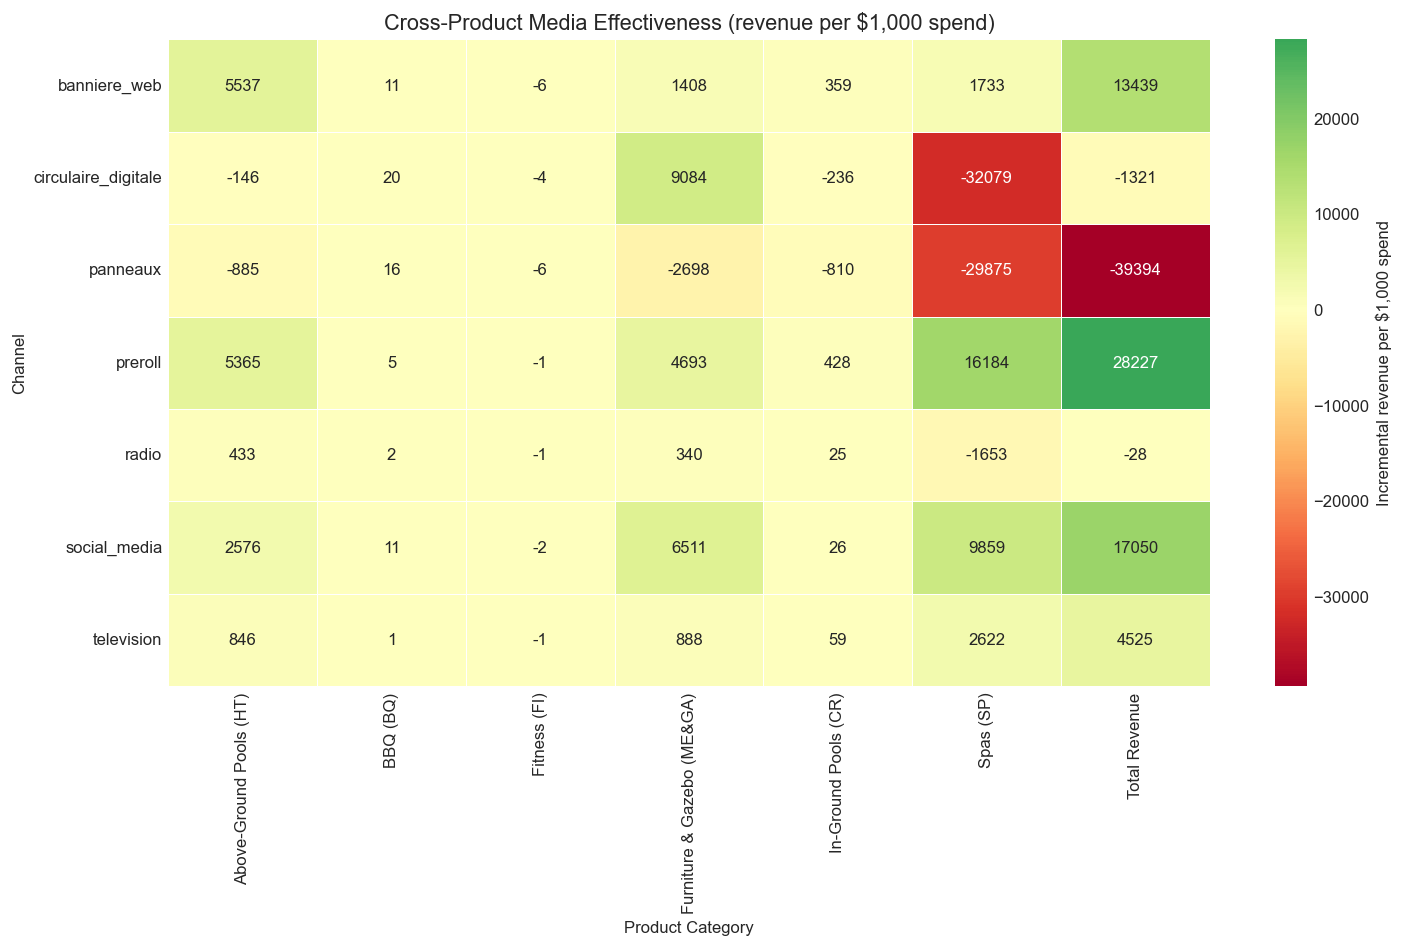

In [119]:
# ---------- Cross-product effectiveness heatmap ----------
pivot = eff_df.pivot_table(index='channel', columns='product',
                           values='marginal_per_1000')

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Incremental revenue per $1,000 spend'})
ax.set_title('Cross-Product Media Effectiveness (revenue per $1,000 spend)', fontsize=13)
ax.set_ylabel('Channel')
ax.set_xlabel('Product Category')
plt.savefig(figures_path / 'causal_effectiveness_heatmap.png', dpi=150)
plt.show()

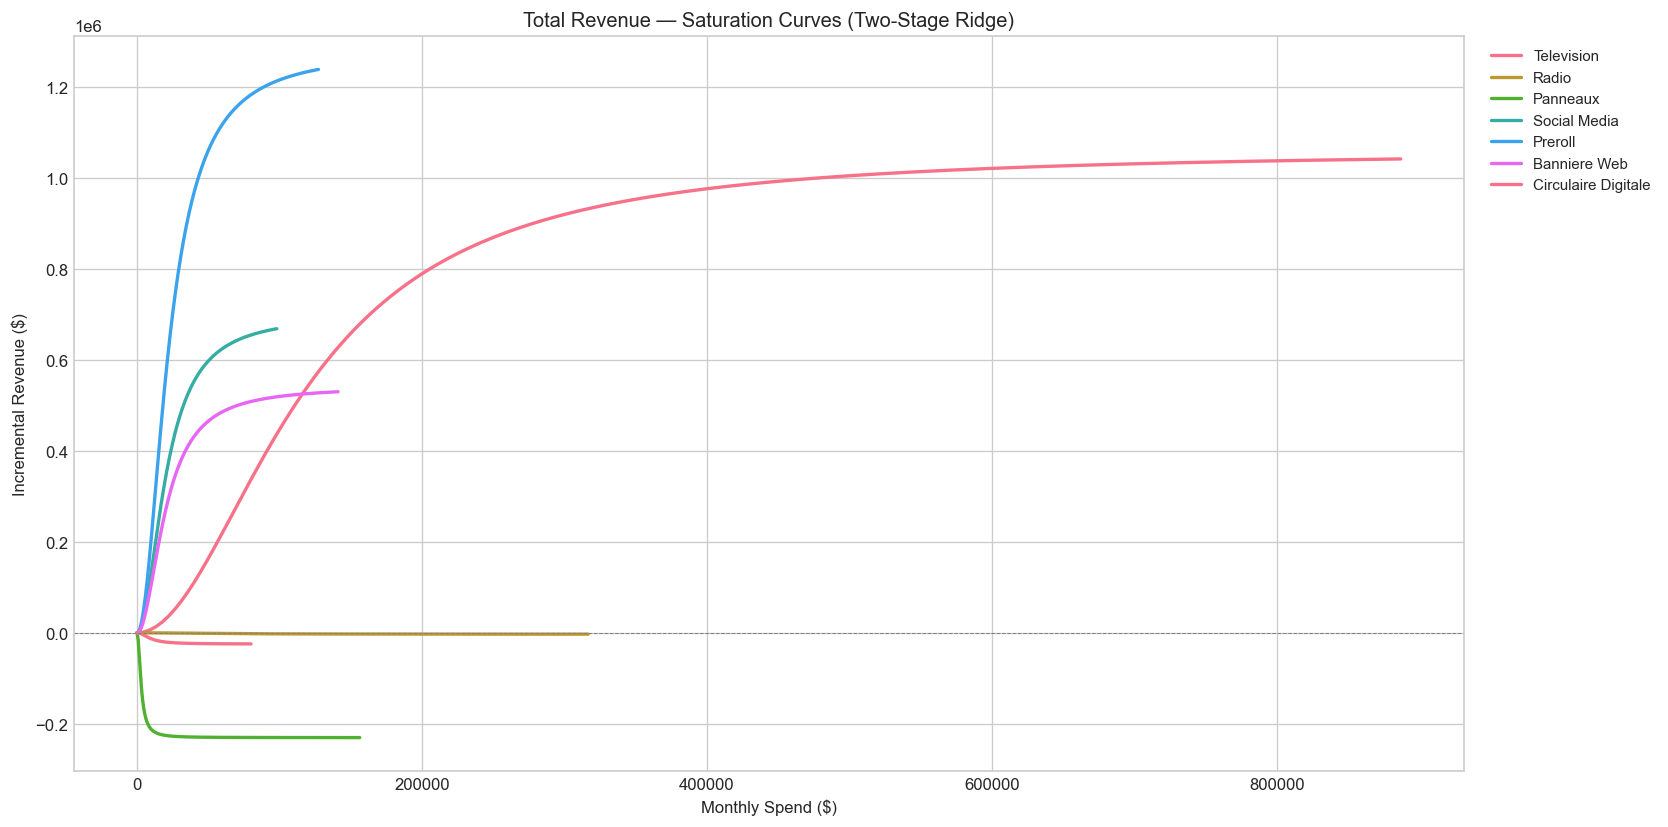

In [120]:
# ---------- Saturation curves (total revenue only) ----------
target = 'total_all_revenue'
fig, ax = plt.subplots(figsize=(14, 7))

model_s2 = ridge_results[target]['model_s2']
saturation_curve_rows = []

for i, ch in enumerate(MEDIA_CHANNELS):
    sat_col = SATURATED_COLS[i]
    beta_s2_orig_i = model_s2.coef_[i] / scaler_media.scale_[i]

    K = SATURATION_PARAMS[ch]['K']
    alpha_h = SATURATION_PARAMS[ch]['alpha']
    lam = DECAY_RATES[ch]

    max_spend = max(df[ch].max() * 2, 1000)
    spend_grid = np.linspace(0, max_spend, 200)
    adstock_grid = spend_grid / (1 - lam)

    # All Hill now (FIX 1)
    sat_grid = hill_saturation(adstock_grid, K, alpha_h)

    # Revenue in original space = beta_orig * saturation_value
    revenue_grid = beta_s2_orig_i * sat_grid

    label = ch.replace('media_', '').replace('_', ' ').title()
    ax.plot(spend_grid, revenue_grid, linewidth=2, label=label)

    for s, r in zip(spend_grid[::20], revenue_grid[::20]):
        saturation_curve_rows.append({
            'product': PRODUCT_LABELS[target],
            'channel': ch.replace('media_', ''),
            'spend': s,
            'incremental_revenue': r,
        })

ax.set_xlabel('Monthly Spend ($)')
ax.set_ylabel('Incremental Revenue ($)')
ax.set_title(f'{PRODUCT_LABELS[target]} — Saturation Curves (Two-Stage Ridge)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.6)

plt.tight_layout()
plt.savefig(figures_path / 'causal_saturation_curves.png', dpi=150)
plt.show()

sat_curves_df = pd.DataFrame(saturation_curve_rows)

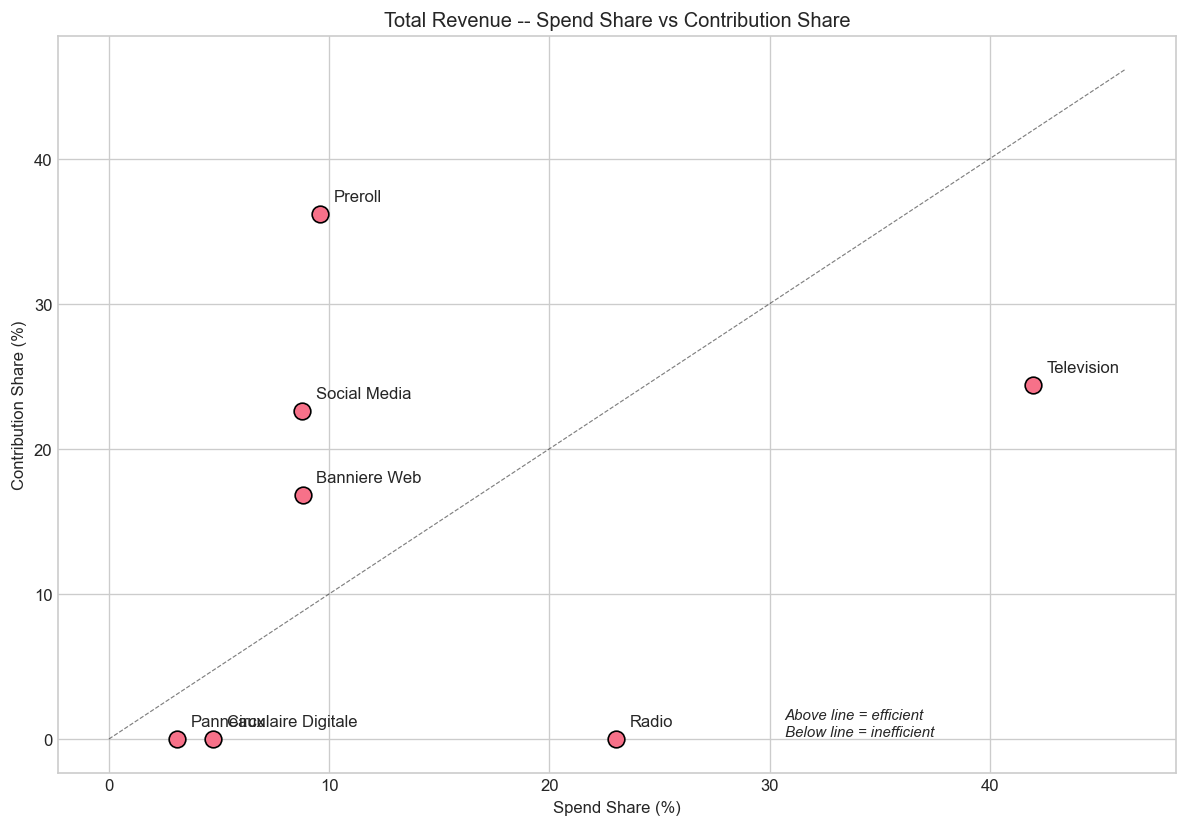

In [121]:
# ---------- Efficiency frontier (total revenue) ----------
target = 'total_all_revenue'
fig, ax = plt.subplots(figsize=(10, 7))

label = PRODUCT_LABELS[target]
sub = eff_df[eff_df['product'] == label].copy()
total_sp = sub['total_spend'].sum()
sub['abs_contrib'] = sub['total_contribution'].clip(lower=0)
total_c = sub['abs_contrib'].sum()
sub['spend_share']  = sub['total_spend'] / total_sp * 100 if total_sp > 0 else 0
sub['contrib_share'] = sub['abs_contrib'] / total_c * 100 if total_c > 0 else 0

ax.scatter(sub['spend_share'], sub['contrib_share'], s=100, zorder=3, edgecolors='k')
for _, r in sub.iterrows():
    ax.annotate(r['channel'].replace('_', ' ').title(),
                (r['spend_share'], r['contrib_share']),
                textcoords='offset points', xytext=(8, 8), fontsize=10)
mn, mx = 0, max(sub['spend_share'].max(), sub['contrib_share'].max()) * 1.1
ax.plot([0, mx], [0, mx], 'k--', linewidth=0.7, alpha=0.5)
ax.set_xlabel('Spend Share (%)')
ax.set_ylabel('Contribution Share (%)')
ax.set_title(f'{label} -- Spend Share vs Contribution Share')
ax.annotate('Above line = efficient\nBelow line = inefficient',
            xy=(0.65, 0.05), xycoords='axes fraction', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig(figures_path / 'causal_efficiency_frontier.png', dpi=150)
plt.show()

---
## Section 7 — Robustness Checks

In [122]:
# ===================================================================
# 7-A  SENSITIVITY TO ADSTOCK DECAY RATES (+/- 0.1)
# ===================================================================
# FIX 3: Sensitivity runs on Stage 2 (residuals ~ media)

decay_variants = {'low': -0.1, 'base': 0.0, 'high': +0.1}
sensitivity_decay = []

for variant_name, delta in decay_variants.items():
    df_tmp = df_raw.copy().sort_values('date').reset_index(drop=True)

    for media_col, spend_col in SPEND_TO_MEDIA.items():
        df_tmp[media_col] = df_tmp[spend_col].fillna(0)

    for ch in MEDIA_CHANNELS:
        lam = np.clip(DECAY_RATES[ch] + delta, 0.05, 0.95)
        df_tmp[f'{ch}_adstock'] = geometric_adstock(df_tmp[ch].fillna(0).values, lam)

    for ch in MEDIA_CHANNELS:
        adstock_col = f'{ch}_adstock'
        K = SATURATION_PARAMS[ch]['K']
        alpha_h = SATURATION_PARAMS[ch]['alpha']
        df_tmp[f'{ch}_saturated'] = hill_saturation(df_tmp[adstock_col].values, K, alpha_h)

    X_tmp = StandardScaler().fit_transform(df_tmp[SATURATED_COLS].fillna(0))

    for target in TARGET_COLS:
        y_resid = residuals[target]
        alpha_r = ridge_results[target]['best_alpha']
        m = Ridge(alpha=alpha_r).fit(X_tmp, y_resid)
        for j, ch in enumerate(MEDIA_CHANNELS):
            sensitivity_decay.append({
                'variant': variant_name,
                'product': PRODUCT_LABELS[target],
                'channel': ch.replace('media_', ''),
                'coef': m.coef_[j],
            })

sens_decay_df = pd.DataFrame(sensitivity_decay)
pivot_decay = sens_decay_df.pivot_table(index=['product', 'channel'], columns='variant', values='coef')
pivot_decay = pivot_decay[['low', 'base', 'high']]

total_label = PRODUCT_LABELS['total_all_revenue']
total_decay = pivot_decay.loc[total_label]
total_decay['sign_stable'] = total_decay.apply(
    lambda r: len(set(np.sign(r.values[r.values != 0]))) <= 1 if any(r.values != 0) else True, axis=1)

print(f'Adstock Decay Sensitivity -- {total_label}:')
print(total_decay.to_string(float_format='{:.0f}'.format))

Adstock Decay Sensitivity -- Total Revenue:
variant                 low    base   high  sign_stable
channel                                                
banniere_web         158597  119843  83788         True
circulaire_digitale   39672   -8253 -25005        False
panneaux            -104813 -100167 -86697         True
preroll              425467  400323 355132         True
radio                -34457    -976  59995        False
social_media         130420  121553  92573         True
television           391526  357027 316824         True


In [123]:
# ===================================================================
# 7-B  SENSITIVITY TO SATURATION PARAMS (K varied by 0.5x and 2x)
# ===================================================================

sat_variants = {'param_low': 0.5, 'base': 1.0, 'param_high': 2.0}
sensitivity_sat = []

for variant_name, mult in sat_variants.items():
    df_tmp = df.copy()
    for ch in MEDIA_CHANNELS:
        K_v = SATURATION_PARAMS[ch]['K'] * mult
        df_tmp[f'{ch}_saturated'] = hill_saturation(df_tmp[f'{ch}_adstock'].values, K_v, 2)

    X_tmp = StandardScaler().fit_transform(df_tmp[SATURATED_COLS].fillna(0))

    for target in TARGET_COLS:
        y_resid = residuals[target]
        alpha_r = ridge_results[target]['best_alpha']
        m = Ridge(alpha=alpha_r).fit(X_tmp, y_resid)
        for j, ch in enumerate(MEDIA_CHANNELS):
            sensitivity_sat.append({
                'variant': variant_name,
                'product': PRODUCT_LABELS[target],
                'channel': ch.replace('media_', ''),
                'coef': m.coef_[j],
            })

sens_sat_df = pd.DataFrame(sensitivity_sat)
pivot_sat = sens_sat_df.pivot_table(index=['product', 'channel'], columns='variant', values='coef')
pivot_sat = pivot_sat[['param_low', 'base', 'param_high']]

total_label = PRODUCT_LABELS['total_all_revenue']
total_sat = pivot_sat.loc[total_label]
print(f'Saturation Parameter Sensitivity -- {total_label}:')
print(total_sat.to_string(float_format='{:.0f}'.format))

Saturation Parameter Sensitivity -- Total Revenue:
variant              param_low    base  param_high
channel                                           
banniere_web             22284  119843      208826
circulaire_digitale     -29565   -8253       11314
panneaux                -92718 -100167      -84446
preroll                 284421  400323      450962
radio                    93659    -976      -84445
social_media            100068  121553      171044
television              278796  357027      458958


In [124]:
# ===================================================================
# 7-C  LEAVE-ONE-OUT INFLUENCE ANALYSIS (total revenue only)
# ===================================================================

target = 'total_all_revenue'
alpha_r = ridge_results[target]['best_alpha']
y_resid = residuals[target]
full_coefs = ridge_results[target]['model_s2'].coef_

loo_influence = []
for drop_i in range(len(df)):
    mask = np.ones(len(df), dtype=bool)
    mask[drop_i] = False
    X_loo = X_media_scaled[mask]
    y_loo = y_resid[mask]
    m = Ridge(alpha=alpha_r).fit(X_loo, y_loo)
    for j, ch in enumerate(MEDIA_CHANNELS):
        loo_influence.append({
            'product': PRODUCT_LABELS[target],
            'dropped_month': str(df['date'].iloc[drop_i].date()),
            'channel': ch.replace('media_', ''),
            'coef_full': full_coefs[j],
            'coef_loo': m.coef_[j],
            'coef_change': m.coef_[j] - full_coefs[j],
        })

loo_df = pd.DataFrame(loo_influence)

loo_summary = loo_df.groupby(['product', 'channel']).agg(
    max_abs_change=('coef_change', lambda x: x.abs().max()),
    mean_abs_change=('coef_change', lambda x: x.abs().mean()),
).reset_index()

print(f'Leave-One-Out Influence -- {PRODUCT_LABELS[target]}:')
print(loo_summary.to_string(index=False, float_format='{:.3f}'.format))

Leave-One-Out Influence -- Total Revenue:
      product             channel  max_abs_change  mean_abs_change
Total Revenue        banniere_web       54487.893        17019.746
Total Revenue circulaire_digitale       70791.099        19259.806
Total Revenue            panneaux       79562.630        22258.823
Total Revenue             preroll       50689.655        15060.267
Total Revenue               radio       67639.196        16589.454
Total Revenue        social_media       82642.108        19219.742
Total Revenue          television       74990.639        18977.474


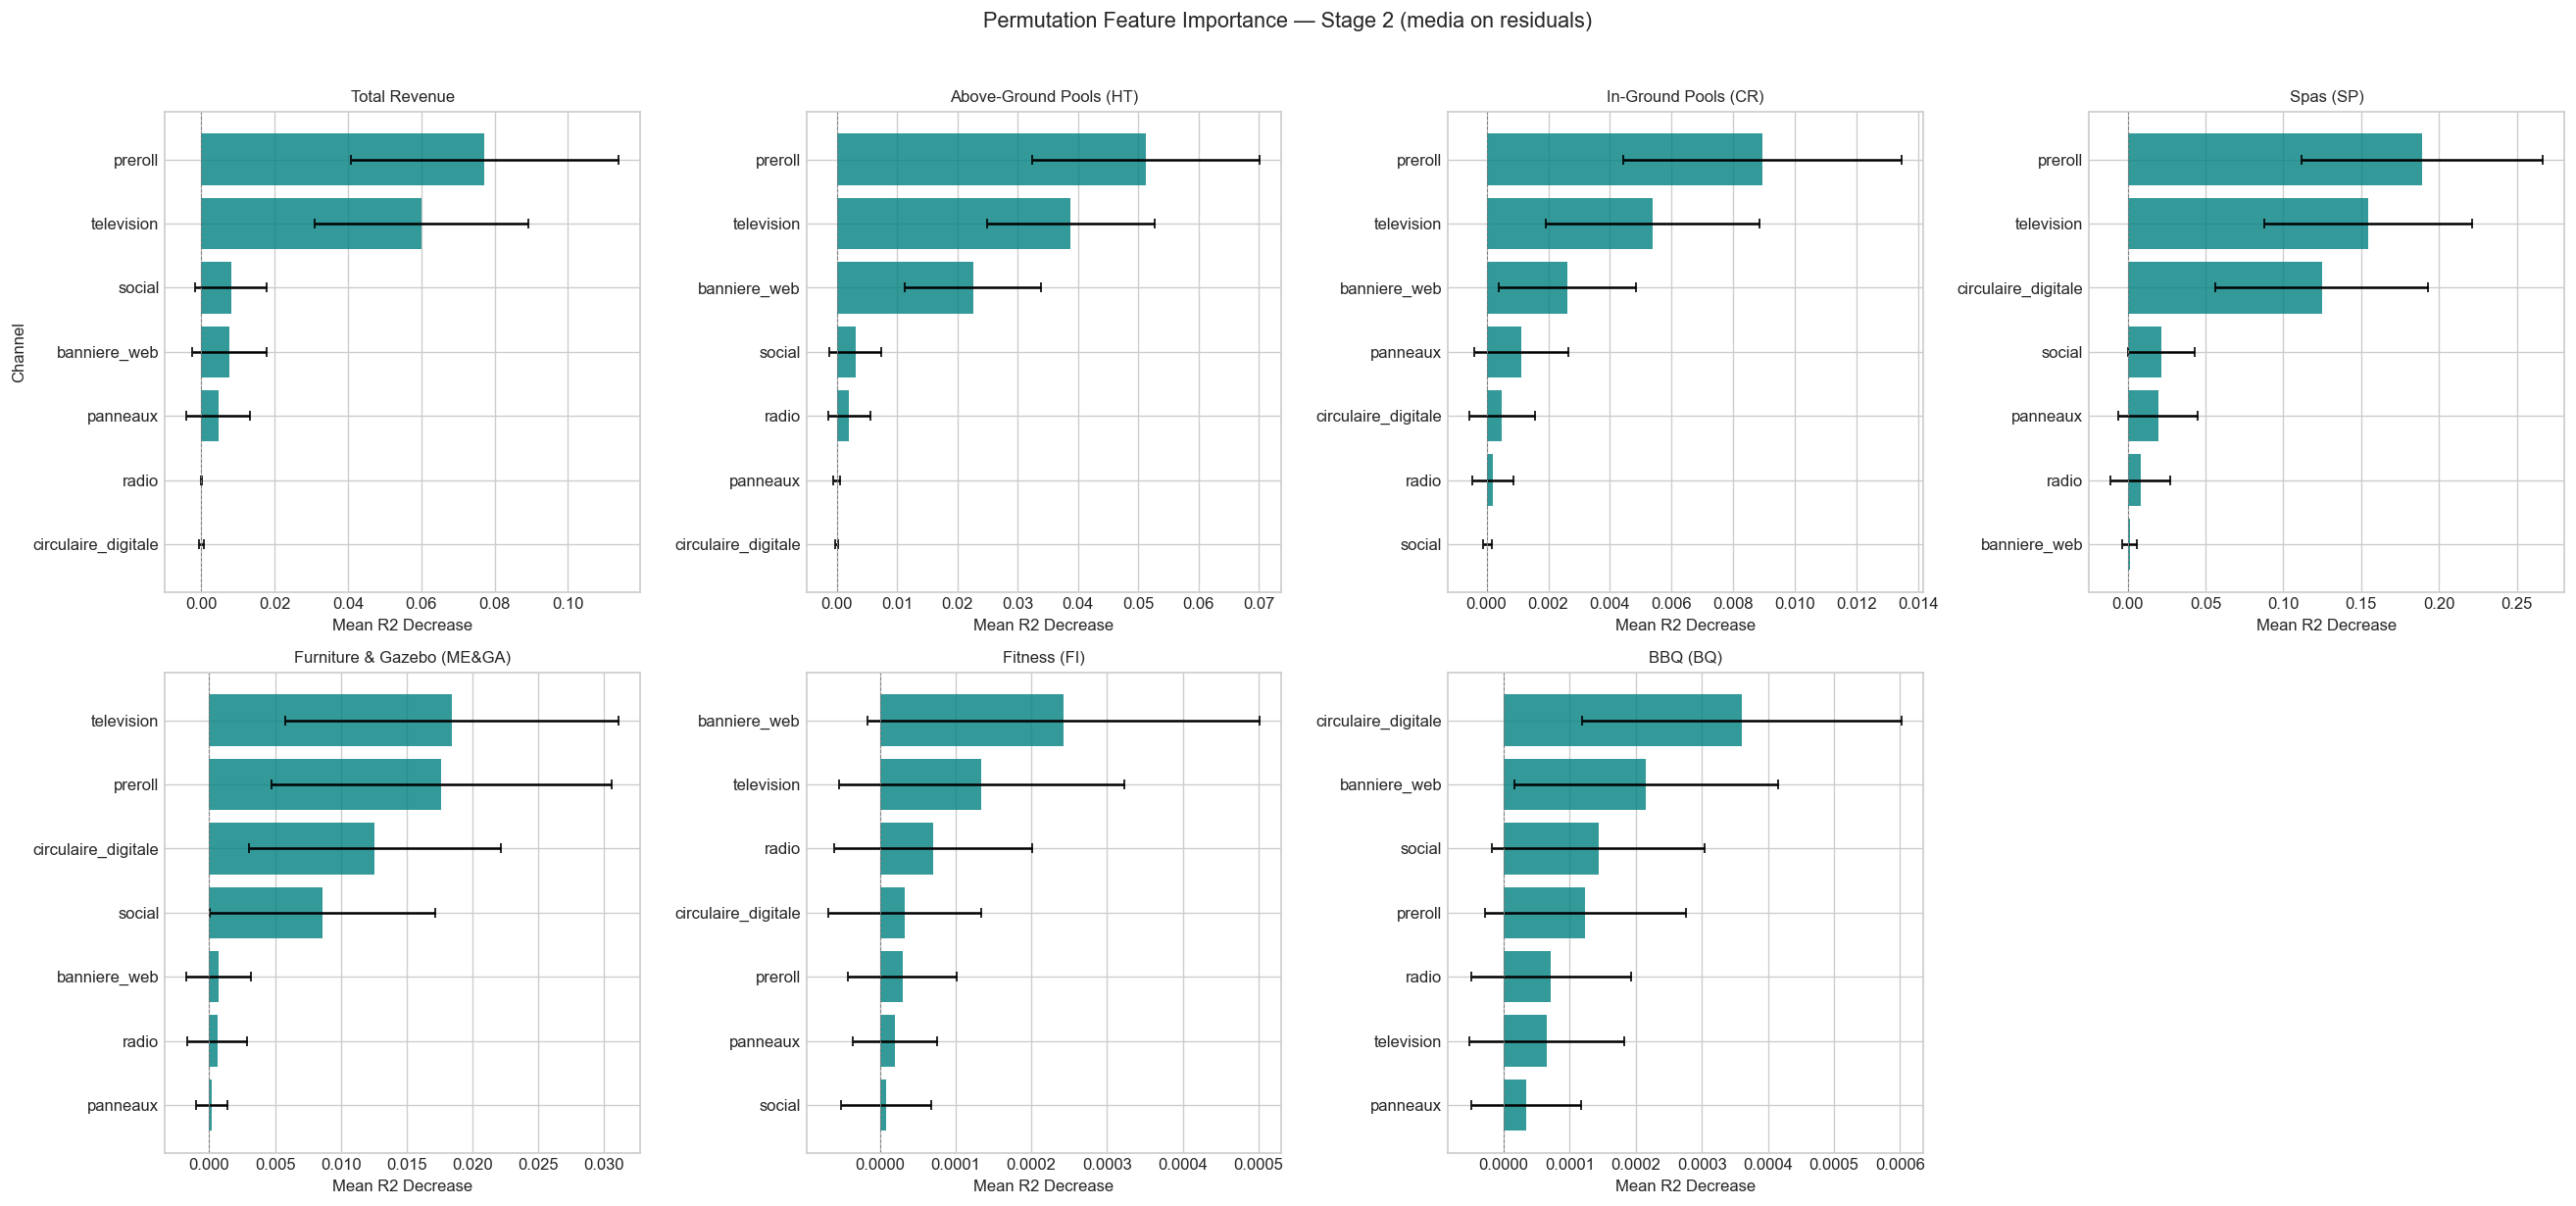

In [125]:
# ===================================================================
# 7-D  PERMUTATION FEATURE IMPORTANCE (2x4 grid)
# ===================================================================
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    model_s2 = ridge_results[target]['model_s2']
    y_resid = residuals[target]

    perm = permutation_importance(model_s2, X_media_scaled, y_resid, n_repeats=100,
                                  random_state=42, scoring='r2')
    perm_df = pd.DataFrame({
        'feature': SATURATED_COLS,
        'importance_mean': perm.importances_mean,
        'importance_std':  perm.importances_std,
    }).sort_values('importance_mean', ascending=True)

    perm_df['label'] = perm_df['feature'].str.replace('media_', '').str.replace('_saturated', '')

    ax.barh(perm_df['label'], perm_df['importance_mean'], alpha=0.8, color='teal')
    ax.errorbar(perm_df['importance_mean'], perm_df['label'],
                xerr=perm_df['importance_std'],
                fmt='none', ecolor='black', capsize=3)
    ax.set_xlabel('Mean R2 Decrease')
    ax.set_title(f'{PRODUCT_LABELS[TARGET_COLS[idx]]}', fontsize=10)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.6)

fig.delaxes(axes[-1])
axes[0].set_ylabel('Channel')
fig.suptitle('Permutation Feature Importance — Stage 2 (media on residuals)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'causal_permutation_importance.png', dpi=150)
plt.show()

In [126]:
# ===================================================================
# 7-E  ROBUSTNESS SUMMARY (total revenue)
# ===================================================================
target = 'total_all_revenue'
label = PRODUCT_LABELS[target]
robustness_rows = []

for ch in MEDIA_CHANNELS:
    ch_short = ch.replace('media_', '')

    adstock_sub = sens_decay_df[(sens_decay_df['product'] == label) &
                                (sens_decay_df['channel'] == ch_short)]
    adstock_signs = np.sign(adstock_sub['coef'].values)
    adstock_stable = len(set(adstock_signs[adstock_signs != 0])) <= 1

    sat_sub = sens_sat_df[(sens_sat_df['product'] == label) &
                          (sens_sat_df['channel'] == ch_short)]
    sat_signs = np.sign(sat_sub['coef'].values)
    sat_stable = len(set(sat_signs[sat_signs != 0])) <= 1

    loo_sub_v = loo_summary[(loo_summary['product'] == label) &
                            (loo_summary['channel'] == ch_short)]
    base_coef = abs(ridge_results[target]['model_s2'].coef_[
        SATURATED_COLS.index(f'{ch}_saturated')])
    loo_stable = True
    if len(loo_sub_v) > 0 and base_coef > 0:
        loo_stable = loo_sub_v['max_abs_change'].values[0] < 0.5 * base_coef

    bs = boot_summary[target]
    bs_row = bs[bs['feature'] == f'{ch}_saturated'].iloc[0]
    ci_excludes_zero = (bs_row['ci_lower'] > 0) or (bs_row['ci_upper'] < 0)

    robustness_rows.append({
        'Channel':  ch_short,
        'Adstock-stable':    'Yes' if adstock_stable else 'No',
        'Saturation-stable': 'Yes' if sat_stable else 'No',
        'LOO-stable':        'Yes' if loo_stable else 'No',
        'CI-excludes-0':     'Yes' if ci_excludes_zero else 'No',
    })

robust_df = pd.DataFrame(robustness_rows)
print(f'Robustness Summary -- {label}:')
print(robust_df.to_string(index=False))

Robustness Summary -- Total Revenue:
            Channel Adstock-stable Saturation-stable LOO-stable CI-excludes-0
         television            Yes               Yes        Yes           Yes
              radio             No                No         No            No
           panneaux            Yes               Yes         No            No
       social_media            Yes               Yes         No            No
            preroll            Yes               Yes        Yes           Yes
       banniere_web            Yes               Yes        Yes            No
circulaire_digitale             No                No         No            No


---
## Section 8 — Limitations & Causal Interpretation

### Small-sample caveats
- **N = 36**: With 36 monthly observations and 14 parameters, statistical power is improved but still limited. Ridge shrinkage is essential.
- **Wide confidence intervals** — some channels' CIs cross zero. Absence of significance does not equal absence of effect.

### Identification assumptions
1. **Conditional exogeneity** — after controlling for seasonality and weather, the remaining variation in media spend is unrelated to unobserved demand shocks.
2. **No simultaneity** — revenue causes no immediate spend adjustment within the same month.
3. **Correct functional form** — geometric adstock and Hill saturation are assumed; the true response shape is unknown.
4. **Stable coefficients** — the relationship between spend and revenue is assumed constant across FY2023-FY2025.

### What these results CAN vs CANNOT say
| CAN | CANNOT |
|-----|--------|
| Identify which channels have the strongest *association* with revenue after controlling for seasonality | Prove strict causation without experimental variation |
| Provide directional guidance on channel efficiency | Give precise point estimates (CIs are wide) |
| Flag channels that are likely saturated | Rule out channels whose CIs include zero |
| Compare relative effectiveness across 6 product categories | Estimate individual-level response |

---
## Section 9 — Outputs & Next Steps

### Deliverables
1. **Effectiveness table** — `media_effectiveness_results.csv` (marginal effects per product per channel)
2. **Saturation curves** — `saturation_curves.csv` (spend vs incremental revenue)
3. **Robustness summary** — `robustness_summary.csv`
4. **Model parameters** — `causal_model_params.json`

### How this feeds into budget optimization
- The effectiveness table shows how much additional revenue each $1,000 of spend generates per channel.
- The saturation curves show diminishing returns — where channels are over/under-invested.
- The efficiency frontier shows which channels are over-/under-indexed relative to their contribution.

In [127]:
# ---------- Save outputs ----------

# 1. Effectiveness table
eff_df.to_csv(processed_path / 'media_effectiveness_results.csv', index=False)
print(f'Saved: {processed_path / "media_effectiveness_results.csv"}')

# 2. Saturation curves
sat_curves_rows = []
for ch in MEDIA_CHANNELS:
    ch_short = ch.replace('media_', '')
    K = SATURATION_PARAMS[ch]['K']
    alpha_h = SATURATION_PARAMS[ch]['alpha']
    x_range = np.linspace(0, df[f'{ch}_adstock'].max() * 1.5, 100)
    y_sat = hill_saturation(x_range, K, alpha_h)
    for x_val, y_val in zip(x_range, y_sat):
        sat_curves_rows.append({'channel': ch_short, 'spend': x_val, 'saturation': y_val})
sat_curves_df = pd.DataFrame(sat_curves_rows)
sat_curves_df.to_csv(processed_path / 'saturation_curves.csv', index=False)
print(f'Saved: {processed_path / "saturation_curves.csv"}')

# 3. Robustness summary
robust_df.to_csv(processed_path / 'robustness_summary.csv', index=False)
print(f'Saved: {processed_path / "robustness_summary.csv"}')

# 4. Model parameters (two-stage)
target = 'total_all_revenue'
model_s2 = ridge_results[target]['model_s2']
beta_s2_orig = model_s2.coef_ / scaler_media.scale_
s2_intercept_orig = model_s2.intercept_ - np.sum(model_s2.coef_ * scaler_media.mean_ / scaler_media.scale_)

y_actual = df[target].values
y_seasonal = ridge_results[target]['y_seasonal']
total_media = sum(beta_s2_orig[j] * df[SATURATED_COLS[j]].sum() for j in range(len(SATURATED_COLS)))
total_revenue = y_actual.sum()

model_params = {
    'model_type': 'two_stage_ridge',
    'stage1_description': 'Revenue ~ Controls (seasonal baseline)',
    'stage2_description': 'Residuals ~ Media (incremental lift)',
    'decay_rates': {k.replace('media_', ''): v for k, v in DECAY_RATES.items()},
    'saturation_params': {k.replace('media_', ''): v for k, v in SATURATION_PARAMS.items()},
    'ridge_alphas_s2': {PRODUCT_LABELS[t]: float(ridge_results[t]['best_alpha']) for t in TARGET_COLS},
    'ridge_r2_full': {PRODUCT_LABELS[t]: float(ridge_results[t]['r2']) for t in TARGET_COLS},
    'ridge_r2_s1': {PRODUCT_LABELS[t]: float(ridge_results[t]['r2_s1']) for t in TARGET_COLS},
    'ridge_r2_s2': {PRODUCT_LABELS[t]: float(ridge_results[t]['r2_s2']) for t in TARGET_COLS},
    'intercept_s2_std': float(model_s2.intercept_),
    'intercept_s2_orig': float(s2_intercept_orig),
    'coefs_s2_std': {SATURATED_COLS[j]: float(model_s2.coef_[j]) for j in range(len(SATURATED_COLS))},
    'coefs_s2_orig': {SATURATED_COLS[j]: float(beta_s2_orig[j]) for j in range(len(SATURATED_COLS))},
    'media_share_pct': float(total_media / total_revenue * 100),
    'seasonal_share_pct': float(y_seasonal.sum() / total_revenue * 100),
    'scaler_media_mean': scaler_media.mean_.tolist(),
    'scaler_media_scale': scaler_media.scale_.tolist(),
    'feature_cols': SATURATED_COLS,
    'control_cols': CONTROL_COLS,
    'media_channels': [ch.replace('media_', '') for ch in MEDIA_CHANNELS],
}

import json as json_mod
with open(processed_path / 'causal_model_params.json', 'w') as f:
    json_mod.dump(model_params, f, indent=2)
print(f'Saved: {processed_path / "causal_model_params.json"}')

Saved: /Users/tuta/Desktop/busa693-clubpiscine/data/processed/media_effectiveness_results.csv
Saved: /Users/tuta/Desktop/busa693-clubpiscine/data/processed/saturation_curves.csv
Saved: /Users/tuta/Desktop/busa693-clubpiscine/data/processed/robustness_summary.csv
Saved: /Users/tuta/Desktop/busa693-clubpiscine/data/processed/causal_model_params.json


In [128]:
# ---------- Final summary ----------
print('=' * 72)
print('  NOTEBOOK 06 -- CAUSAL INFERENCE: COMPLETE')
print('  (Two-Stage Ridge with Fixes 1-5)')
print('=' * 72)
print()
print('Two-Stage Ridge Results:')
for target in TARGET_COLS:
    r = ridge_results[target]
    print(f'  {PRODUCT_LABELS[target]:30s}  alpha_s2={r["best_alpha"]:>8.2f}  '
          f'R2_full={r["r2"]:.3f}  R2_s1={r["r2_s1"]:.3f}  R2_s2={r["r2_s2"]:.3f}  '
          f'MAE=${r["mae"]:>12,.0f}')
print()

# Decomposition summary
target = 'total_all_revenue'
y_actual = df[target].values
y_seasonal = ridge_results[target]['y_seasonal']
model_s2 = ridge_results[target]['model_s2']
beta_s2_orig = model_s2.coef_ / scaler_media.scale_
total_media = sum(beta_s2_orig[j] * df[SATURATED_COLS[j]].sum() for j in range(len(SATURATED_COLS)))
total_revenue = y_actual.sum()
seasonal_pct = y_seasonal.sum() / total_revenue * 100
media_pct = total_media / total_revenue * 100

print(f'Contribution Decomposition (Total Revenue):')
print(f'  Seasonal baseline: {seasonal_pct:.1f}%')
print(f'  Media contribution: {media_pct:.1f}%')
print(f'  Residual: {100 - seasonal_pct - media_pct:.1f}%')
print()
print('Fixes applied:')
print('  FIX 1: All Hill saturation [0,1] (was mixed log/power/hill)')
print('  FIX 2: Correct contribution decomposition (original-space coefficients)')
print('  FIX 3: Two-stage Ridge (seasonality first, then media on residuals)')
print('  FIX 4: TimeSeriesSplit CV (was LOOCV)')
print('  FIX 5: Sanity check guardrails')
print()
print('Output files:')
print(f'  data/processed/media_effectiveness_results.csv')
print(f'  data/processed/saturation_curves.csv')
print(f'  data/processed/robustness_summary.csv')
print(f'  data/processed/causal_model_params.json')
print()
print('Figures saved to reports/figures/:')
for f in sorted(figures_path.glob('causal_*.png')):
    print(f'  {f.name}')

  NOTEBOOK 06 -- CAUSAL INFERENCE: COMPLETE
  (Two-Stage Ridge with Fixes 1-5)

Two-Stage Ridge Results:
  Total Revenue                   alpha_s2=   89.07  R2_full=0.860  R2_s1=0.835  R2_s2=0.155  MAE=$   2,796,210
  Above-Ground Pools (HT)         alpha_s2=  252.35  R2_full=0.751  R2_s1=0.716  R2_s2=0.122  MAE=$     827,741
  In-Ground Pools (CR)            alpha_s2=  821.43  R2_full=0.558  R2_s1=0.550  R2_s2=0.018  MAE=$     331,761
  Spas (SP)                       alpha_s2=   16.83  R2_full=0.862  R2_s1=0.786  R2_s2=0.353  MAE=$     559,122
  Furniture & Gazebo (ME&GA)      alpha_s2=  191.16  R2_full=0.847  R2_s1=0.838  R2_s2=0.059  MAE=$   1,457,661
  Fitness (FI)                    alpha_s2=10000.00  R2_full=0.577  R2_s1=0.577  R2_s2=0.001  MAE=$      50,483
  BBQ (BQ)                        alpha_s2=10000.00  R2_full=0.796  R2_s1=0.795  R2_s2=0.001  MAE=$     130,595

Contribution Decomposition (Total Revenue):
  Seasonal baseline: 100.0%
  Media contribution: 10.5%
  Residual